# Scar Threshold: generalized fire pipeline

One notebook, one fire, perimeter to web export. Everything that changes between fires lives in the `CONFIG` block in Cell 1. Nothing below it should need editing.

**How to run a fire**
1. Fill in `CONFIG` in Cell 1. You need the fire's name, rough center, published acres, ignition date, and two search windows. Leave `pre_date` and `post_date` as `None`.
2. Run Cells 1 to 4. Cell 4 prints the candidate scenes and **suggests** a pre and post date.
3. Look at the table. If you agree with the suggestion, just keep running. If not, type your own dates into `CONFIG` and rerun Cell 1 and Cell 4.
4. Run everything else top to bottom, and glance at the Cell 8 dNBR map: the cloud mask can miss smoke.
5. If `reference_dir` is set, Cell 22 checks the run against a previous validated one.

**Changes from the first generalized draft**
* Scene dates and search windows moved into `CONFIG`, with checks that they are in a sensible order.
* Dates can be left as `None`: Cell 4 suggests them from the scene table, and a date typed into `CONFIG` always wins.
* `search_box` and the area guards are now built from two numbers off the incident page: `approx_center` and `published_acres`.
* Post-fire date for Bridge corrected to 2024-09-29 (the draft still had a Line Fire date).
* Scene search restored to the original in-perimeter cloud scoring, and duplicate granules for the same tile are caught.
* Provenance no longer stores signed URLs (they expire). It stores scene IDs, tiles, platform and processing baseline.
* pysheds pinned to 0.5, with a version tripwire.
* Variable names that were reused between cells for different things were renamed (`shape`, `finite`, `mh`, `inside`, `T`/`F`/`S`, `areas`, `m`, `holes`, `b`).
* BAER coverage is checked and recorded as `HAS_BAER` instead of assumed.
* The baseline reproduction check from notebook 04 is back (end of Cell 19).
* Manifest: ignition date and display name come from `CONFIG`, and the new fire is **merged** into the existing `fires.json` instead of replacing it.
* New Cell 22: regression check against a reference run.

## Cell 1: Configuration, environment, and storage

Sets every run parameter in `CONFIG`, checks the dates make sense, mounts Drive, and creates the output folders.

**CONFIG fields**
* `fire_id`: folder and file slug, e.g. `line_2024`. Also the id the web map uses.
* `display_name`: what the map shows, e.g. `Line Fire`.
* `fire_name_query`: text matched against the perimeter service's fire name field.
* `ignition_date`: goes into the manifest and is used to check the scene dates.
* `approx_center`: rough (lon, lat) of the fire, from the InciWeb or CAL FIRE incident page. Note the order: longitude first.
* `published_acres`: final acreage from the incident page.
* `pre_window` / `post_window`: date ranges searched for candidate scenes in Cell 4. Pre window ends before ignition. Post window starts once the fire is mostly contained and ends before winter rain or snow.
* `pre_date` / `post_date`: leave as `None` and Cell 4 suggests them. Set them to pin specific scenes (the validated Bridge run pins them).

**Built from those, and printed so you can see them**
* Search box: `approx_center` plus or minus 0.3 degrees (about 20 miles). Only there to exclude same-named fires elsewhere.
* Area guards: half and double the published area (acres / 247.1 = km²). Only there to catch a wrong perimeter.

Neither one changes any results. They only decide whether the perimeter query is trusted.

**Example: Line Fire**
```python
CONFIG = {
    "fire_id":         "line_2024",
    "display_name":    "Line Fire",
    "fire_name_query": "LINE",
    "target_year":     2024,
    "ignition_date":   "2024-09-05",
    "approx_center":   (-117.06, 34.16),
    "published_acres": 43978,
    "pre_window":      "2024-08-01/2024-09-04",
    "post_window":     "2024-10-03/2024-11-15",
    "pre_date":        None,
    "post_date":       None,
    "reference_dir":   None,
}
```
* `reference_dir`: a Drive folder (under `postfire-debris-flow/`) holding a previous validated run to compare against in Cell 22. Use `None` for a new fire.

**What to check:** the date checks print OK. If one fails, fix `CONFIG` before going further.

In [1]:
# Cell 1 --- configuration, environment, and storage

%cd /content

!pip install -q pystac-client planetary-computer

import json
import os
from pathlib import Path
from google.colab import drive

# --- Run configuration --------------------------------------------------------
# The ONLY place fire-specific values live. Values below reproduce Bridge 2024.
CONFIG = {
    "fire_id":         "line_2024",
    "display_name":    "Line Fire",
    "fire_name_query": "LINE",
    "target_year":     2024,
    "ignition_date":   "2024-09-05",

    # From the incident page. Longitude first.
    "approx_center":   (-117.06, 34.16),
    "published_acres": 43978,

    # Sentinel-2 search windows (Cell 4)
    "pre_window":      "2024-08-01/2024-09-04",
    "post_window":     "2024-10-03/2024-11-15",

    # Scene dates. None = use the Cell 4 suggestion. Bridge pins its validated dates.
    "pre_date":        "2024-08-20",
    "post_date":       "2024-10-19",

    # Previous validated run to compare against in Cell 22, or None
    "reference_dir":   "BridgeOrig_2024",
}

# --- Guards built from the incident-page numbers ------------------------------
# These never change results; they only decide whether the perimeter query is trusted.
BOX_MARGIN_DEG = 0.3            # about 20 miles at California latitudes
ACRES_PER_KM2 = 247.105

center_x, center_y = CONFIG['approx_center']
assert -180 <= center_x <= 0 and 0 <= center_y <= 90, \
    'approx_center must be (longitude, latitude), e.g. (-117.71, 34.31)'
SEARCH_BOX = (center_x - BOX_MARGIN_DEG, center_y - BOX_MARGIN_DEG,
              center_x + BOX_MARGIN_DEG, center_y + BOX_MARGIN_DEG)
PUBLISHED_KM2 = CONFIG['published_acres'] / ACRES_PER_KM2
MIN_AREA_KM2 = 0.5 * PUBLISHED_KM2
MAX_AREA_KM2 = 2.0 * PUBLISHED_KM2

# --- Check the dates before anything touches the network ----------------------
# ISO dates (YYYY-MM-DD) sort correctly as plain strings, so string comparison works.
def in_window(day, window):
    start, end = window.split('/')
    return start <= day <= end

ign = CONFIG['ignition_date']
date_checks = {
    'pre_window ends before ignition':  CONFIG['pre_window'].split('/')[1] <= ign,
    'post_window starts after ignition': CONFIG['post_window'].split('/')[0] > ign,
}
if CONFIG['pre_date'] is not None:
    date_checks['pre_date inside pre_window'] = in_window(CONFIG['pre_date'], CONFIG['pre_window'])
if CONFIG['post_date'] is not None:
    date_checks['post_date inside post_window'] = in_window(CONFIG['post_date'], CONFIG['post_window'])

for check_name, passed in date_checks.items():
    print(f'{"OK  " if passed else "FAIL"} {check_name}')
if not all(date_checks.values()):
    raise ValueError('Fix the dates in CONFIG before continuing.')

# --- Mount Google Drive -------------------------------------------------------
drive.mount('/content/drive')

# --- Storage ------------------------------------------------------------------
# Drive root keeps the old project name on purpose; the Drive folder was not renamed.
DRIVE_ROOT = Path('/content/drive/MyDrive/postfire-debris-flow')
FIRE_DIR = DRIVE_ROOT / CONFIG['fire_id']

for sub_dir in ('perimeter', 'severity', 'terrain', 'soils', 'model', 'baer',
                'sensitivity', 'web_export'):
    (FIRE_DIR / sub_dir).mkdir(parents=True, exist_ok=True)

REF_DIR = DRIVE_ROOT / CONFIG['reference_dir'] if CONFIG['reference_dir'] else None

print(f"\nFire        : {CONFIG['display_name']} ({CONFIG['fire_id']})")
print(f'Search box  : {tuple(round(v, 2) for v in SEARCH_BOX)}')
print(f'Area guard  : {MIN_AREA_KM2:,.0f} to {MAX_AREA_KM2:,.0f} km^2 '
      f"(published {CONFIG['published_acres']:,} acres = {PUBLISHED_KM2:,.1f} km^2)")
print(f"Scenes      : pre {CONFIG['pre_date'] or 'suggest in Cell 4'}, "
      f"post {CONFIG['post_date'] or 'suggest in Cell 4'}")
print(f'Output      : {FIRE_DIR}')
if REF_DIR is not None:
    print(f'Reference   : {REF_DIR}  ({"found" if REF_DIR.exists() else "NOT FOUND"})')
    if REF_DIR.resolve() == FIRE_DIR.resolve():
        raise ValueError('reference_dir is the output folder. The comparison would compare a run with itself.')

/content
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 1.8 MB/s eta 0:00:00
OK   pre_window ends before ignition
OK   post_window starts after ignition
OK   pre_date inside pre_window
OK   post_date inside post_window
Mounted at /content/drive

Fire        : Line Fire (line_2024)
Search box  : (-117.36, 33.86, -116.76, 34.46)
Area guard  : 89 to 356 km^2 (published 43,978 acres = 178.0 km^2)
Scenes      : pre 2024-08-20, post 2024-10-19
Output      : /content/drive/MyDrive/postfire-debris-flow/line_2024
Reference   : /content/drive/MyDrive/postfire-debris-flow/BridgeOrig_2024  (found)


## Cell 2: Query candidate perimeters

Queries CAL FIRE FRAP first, then NIFC as a fallback, filtering by both the search box and the fire name. Also works out the UTM zone from the search box, which every later cell uses as the working projection.

**What to check:** the expected fire appears in the table, with roughly the published acreage.

In [2]:
# Cell 2 --- query candidate perimeters

import math
import requests
import geopandas as gpd

AOI_BOX = SEARCH_BOX              # built in Cell 1 from approx_center
TARGET_NAME = CONFIG['fire_name_query'].upper()
TARGET_YEAR = CONFIG['target_year']

# (label, url, name field, year field, acres field), in priority order
CANDIDATE_SERVICES = [
    ('CAL FIRE FRAP, all perimeters',
     'https://services1.arcgis.com/jUJYIo9tSA7EHvfZ/arcgis/rest/services/'
     'California_Historic_Fire_Perimeters/FeatureServer/0/query',
     'FIRE_NAME', 'YEAR_', 'GIS_ACRES'),
    ('CAL FIRE FRAP, 1950+',
     'https://services1.arcgis.com/jUJYIo9tSA7EHvfZ/arcgis/rest/services/'
     'California_Historic_Fire_Perimeters/FeatureServer/2/query',
     'FIRE_NAME', 'YEAR_', 'GIS_ACRES'),
    ('NIFC interagency perimeter history',
     'https://services3.arcgis.com/T4QMspbfLg3qTGWY/arcgis/rest/services/'
     'InterAgencyFirePerimeterHistory_All_Years_View/FeatureServer/0/query',
     'INCIDENT', 'FIRE_YEAR', 'GIS_ACRES'),
]


def query_service(url, where):
    """Server-side filtered query: attribute clause AND intersects the search box."""
    params = {
        'where': where,
        'geometry': ','.join(str(v) for v in AOI_BOX),
        'geometryType': 'esriGeometryEnvelope',
        'inSR': '4326',
        'spatialRel': 'esriSpatialRelIntersects',
        'outFields': '*',
        'outSR': '4326',
        'f': 'geojson',
        'returnGeometry': 'true',
    }
    resp = requests.get(url, params=params, timeout=90)
    resp.raise_for_status()
    return resp.json()


hits, used = None, None
for svc_label, url, name_f, year_f, acres_f in CANDIDATE_SERVICES:
    # Most specific clause first; fall back to looser ones only if nothing matches.
    clauses = [
        f"UPPER({name_f}) LIKE '%{TARGET_NAME}%' AND {year_f} = {TARGET_YEAR}",
        f"UPPER({name_f}) LIKE '%{TARGET_NAME}%' AND {year_f} = '{TARGET_YEAR}'",
        f"UPPER({name_f}) LIKE '%{TARGET_NAME}%'",
        '1=1',
    ]
    for where in clauses:
        try:
            gj = query_service(url, where)
        except Exception as e:
            print(f'[skip] {svc_label:38s} | {where[:44]:44s} -> {type(e).__name__}')
            continue
        feats = gj.get('features', [])
        print(f'[try ] {svc_label:38s} | {where[:44]:44s} -> {len(feats):4d} feature(s)')
        if feats:
            hits, used = gj, (svc_label, where, name_f, year_f)
            break
    if hits:
        break

if not hits:
    raise RuntimeError(
        f"No perimeters matched '{TARGET_NAME}' ({TARGET_YEAR}) within {AOI_BOX}. "
        'Check approx_center (longitude first) or the service URLs.')

PERIM_SOURCE, PERIM_WHERE, NAME_F, YEAR_F = used
gdf_all = gpd.GeoDataFrame.from_features(hits['features'], crs='EPSG:4326')

# UTM zone from the search box centre (= approx_center). Northern hemisphere only (326xx), fine for CA.
center_lon = (AOI_BOX[0] + AOI_BOX[2]) / 2.0
utm_zone = int(math.floor((center_lon + 180) / 6) + 1)
utm_crs = f'EPSG:{32600 + utm_zone}'

gdf_all['_acres'] = gdf_all.to_crs(utm_crs).area / 4046.86

print(f'\nMatched via : {PERIM_SOURCE}')
print(f'Where clause: {PERIM_WHERE}')
print(f'Working CRS : {utm_crs} (UTM zone {utm_zone}N)')
print(f'Candidates  : {len(gdf_all)}\n')

cols = [c for c in (NAME_F, YEAR_F, 'ALARM_DATE', 'CONT_DATE') if c in gdf_all.columns]
perim_preview = gdf_all[cols].copy()
perim_preview['calculated_acres'] = gdf_all['_acres'].round(0)
print(perim_preview.sort_values('calculated_acres', ascending=False).head(20).to_string())

[try ] CAL FIRE FRAP, all perimeters          | UPPER(FIRE_NAME) LIKE '%LINE%' AND YEAR_ = 2 ->    1 feature(s)

Matched via : CAL FIRE FRAP, all perimeters
Where clause: UPPER(FIRE_NAME) LIKE '%LINE%' AND YEAR_ = 2024
Working CRS : EPSG:32611 (UTM zone 11N)
Candidates  : 1

  FIRE_NAME  YEAR_     ALARM_DATE      CONT_DATE  calculated_acres
0      LINE   2024  1725494400000  1734912000000           44834.0


## Cell 3: Select, validate, save, and map the perimeter

Keeps only records from `target_year`, takes the largest, and checks it against three guards before saving anything:
1. Centroid falls inside the search box (built in Cell 1 from `approx_center`).
2. Area is between half and double the published area.
3. Longitude is negative (western hemisphere).

**What to check:** guards pass, the measured area is close to the published one (the ratio is printed), and the map outline looks like the fire. Bridge reference: 226.6 km², ratio about 0.99.

In [3]:
# Cell 3 --- select, validate, dissolve, save, map

import folium
from shapely.ops import unary_union

# --- Selection ----------------------------------------------------------------
cand = gdf_all.copy()
if YEAR_F in cand.columns:
    # Pull a 4-digit year out whatever the field type (int, string, date string).
    yr = cand[YEAR_F].astype(str).str.extract(r'(\d{4})')[0]
    matched = cand[yr == str(TARGET_YEAR)]
    if matched.empty:
        raise RuntimeError(f'No candidate has {YEAR_F} == {TARGET_YEAR}.')
    cand = matched
    print(f'Filtered to {YEAR_F} == {TARGET_YEAR}: {len(cand)} candidate(s)')

sel = cand.sort_values('_acres', ascending=False).head(1)
perim_shape = unary_union(sel.geometry.values)          # WGS84 shapely geometry
perimeter = gpd.GeoDataFrame(geometry=[perim_shape], crs='EPSG:4326')
perim_utm = perimeter.to_crs(utm_crs)

area_km2 = float(perim_utm.area.iloc[0]) / 1e6
acres = area_km2 * 247.105
centroid = perim_shape.centroid
minx, miny, maxx, maxy = perimeter.total_bounds

print('\n--- Selected ---')
for c in [c for c in (NAME_F, YEAR_F) if c in sel.columns]:
    print(f'{c:12s}: {sel.iloc[0][c]}')
print(f'Area        : {area_km2:,.1f} km^2  ({acres:,.0f} acres)')
print(f'vs published: {area_km2 / PUBLISHED_KM2:.2f}x  (1.00 = same as the incident page)')
print(f'Centroid    : {centroid.x:.4f}, {centroid.y:.4f}')
print(f'Bounds      : {minx:.4f}, {miny:.4f} -> {maxx:.4f}, {maxy:.4f}')

# --- Guards: a wrong perimeter is not visually obvious downstream --------------
bx0, by0, bx1, by1 = AOI_BOX
problems = []
if not (bx0 <= centroid.x <= bx1 and by0 <= centroid.y <= by1):
    problems.append(f'centroid {centroid.x:.3f},{centroid.y:.3f} is outside the search box {AOI_BOX}')
if not (MIN_AREA_KM2 <= area_km2 <= MAX_AREA_KM2):
    problems.append(f'area {area_km2:,.1f} km^2 outside the guard range '
                    f'[{MIN_AREA_KM2:,.0f}, {MAX_AREA_KM2:,.0f}]')
if centroid.x >= 0:
    problems.append(f'longitude {centroid.x:.3f} is not negative')
if problems:
    raise ValueError('Perimeter failed validation, nothing saved:\n  - ' + '\n  - '.join(problems))
print('\nGuards passed.')

# --- Geometry detail ----------------------------------------------------------
perim_parts = list(perim_shape.geoms) if hasattr(perim_shape, 'geoms') else [perim_shape]
n_holes = sum(len(p.interiors) for p in perim_parts if p.geom_type == 'Polygon')
print(f'Geometry    : {perim_shape.geom_type}, {len(perim_parts)} part(s), {n_holes} interior hole(s)')

# --- Save ---------------------------------------------------------------------
PERIM_PATH = FIRE_DIR / 'perimeter' / f"{CONFIG['fire_id']}_perimeter.geojson"
perimeter.to_file(PERIM_PATH, driver='GeoJSON')
print(f'Saved       -> {PERIM_PATH}')

# --- Verification map ---------------------------------------------------------
perim_map = folium.Map(location=[centroid.y, centroid.x], zoom_start=10,
                       tiles='OpenStreetMap', control_scale=True)
folium.GeoJson(
    perimeter,
    style_function=lambda _f: {'color': '#ff6b35', 'fillOpacity': 0.25, 'weight': 2},
).add_to(perim_map)
perim_map.fit_bounds([[miny, minx], [maxy, maxx]])
perim_map

Filtered to YEAR_ == 2024: 1 candidate(s)

--- Selected ---
FIRE_NAME   : LINE
YEAR_       : 2024
Area        : 179.6 km^2  (44,387 acres)
vs published: 1.01x  (1.00 = same as the incident page)
Centroid    : -117.0657, 34.1594
Bounds      : -117.1851, 34.0921 -> -116.9398, 34.2177

Guards passed.
Geometry    : MultiPolygon, 28 part(s), 1 interior hole(s)
Saved       -> /content/drive/MyDrive/postfire-debris-flow/line_2024/perimeter/line_2024_perimeter.geojson


## Cell 4: Sentinel-2 scene reconnaissance and date suggestion

Searches Planetary Computer's `sentinel-2-l2a` over both windows in `CONFIG`. For each granule it measures how much of the perimeter the tile covers, and how cloudy the SCL band is **inside the perimeter** (not the whole-scene cloud number, which can be high while the fire itself is clear).

It then rolls granules up into one row per date and marks a date **usable** if:
* the tiles that day cover the whole perimeter (`perim_cover` at least 99.9%),
* all granules that day come from one satellite,
* cloud and snow inside the perimeter are both at most 1%.

**The suggestion:** the earliest usable post date, paired with the latest usable pre date from the same satellite. Close to ignition before, soon after containment after, same sensor on both. If no same-satellite pair exists it pairs them anyway and warns.

**What to check**
* The rows marked `<-- suggested` and `<-- config`. A date in `CONFIG` always wins over the suggestion.
* If you disagree with the suggestion, type your dates into `CONFIG` and rerun Cell 1 and this cell.
* The SCL cloud mask often misses **smoke**. The Cell 8 dNBR map is the real check.

Bridge reference: tiles 11SMT and 11SMU, both dates Sentinel-2B, zero cloud. Bridge pins its dates in `CONFIG`, so the suggestion is informational there.

In [4]:
# Cell 4 --- STAC query, in-perimeter cloud scoring, and a date suggestion

import numpy as np
import pandas as pd
import rasterio
import planetary_computer
from pystac_client import Client
from rasterio.windows import from_bounds
from rasterio.warp import transform_bounds
from shapely.geometry import shape as shp_shape
from shapely.ops import unary_union

PRE_WINDOW = CONFIG['pre_window']
POST_WINDOW = CONFIG['post_window']
BAD_SCL = {3, 8, 9, 10}      # cloud shadow, cloud medium, cloud high, cirrus
SNOW_SCL = {11}
CLEAR_MAX = 0.01             # at most 1% cloud or snow inside the perimeter
FULL_COVER = 0.999           # tiles must cover at least 99.9% of the perimeter

catalog = Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=planetary_computer.sign_inplace,
)

aoi_geom = json.loads(perimeter.to_json())['features'][0]['geometry']
perim_area = float(perim_utm.area.iloc[0])

SCENE_COLUMNS = ['date', 'tile', 'platform', 'cover_frac', 'cloud_in_aoi',
                 'snow_in_aoi', 'scene_cloud', 'baseline', 'id']


def search(window):
    # Loose scene-level cloud filter; the in-perimeter score below is what matters.
    return list(catalog.search(
        collections=['sentinel-2-l2a'],
        intersects=aoi_geom,
        datetime=window,
        query={'eo:cloud_cover': {'lt': 60}},
    ).items())


def perimeter_fraction(geom_4326):
    """Fraction of the burn perimeter covered by a WGS84 geometry."""
    overlap = perim_shape.intersection(geom_4326)
    if overlap.is_empty:
        return 0.0
    return float(gpd.GeoSeries([overlap], crs='EPSG:4326').to_crs(utm_crs).area.iloc[0] / perim_area)


def scl_stats(item):
    """Cloud and snow fractions of the SCL band, windowed to the perimeter bbox."""
    with rasterio.open(item.assets['SCL'].href) as src:
        bb = transform_bounds('EPSG:4326', src.crs, *perimeter.total_bounds)
        win = from_bounds(*bb, transform=src.transform).round_offsets().round_lengths()
        arr = src.read(1, window=win, boundless=True, fill_value=0)
    valid = arr > 0
    n_valid = int(valid.sum())
    if n_valid == 0:
        return np.nan, np.nan
    cloud = np.isin(arr, list(BAD_SCL)) & valid
    snow = np.isin(arr, list(SNOW_SCL)) & valid
    return float(cloud.sum() / n_valid), float(snow.sum() / n_valid)


def report(phase_label, window):
    """Search one window and score every granule that meaningfully covers the fire."""
    items = search(window)
    print(f'{phase_label}: {len(items)} scene(s) in {window}, scoring cloud inside the perimeter...')
    rows = []
    for it in items:
        cov = perimeter_fraction(shp_shape(it.geometry))
        if cov < 0.01:
            continue      # granule barely clips the fire, not worth reading
        cloud, snow = scl_stats(it)
        rows.append({
            'date': it.datetime.date().isoformat(),
            'tile': it.properties.get('s2:mgrs_tile', '?'),
            'platform': it.properties.get('platform', '?'),
            'cover_frac': round(cov, 3),
            'cloud_in_aoi': round(cloud, 3) if cloud == cloud else None,
            'snow_in_aoi': round(snow, 3) if snow == snow else None,
            'scene_cloud': round(it.properties.get('eo:cloud_cover', -1), 1),
            'baseline': it.properties.get('s2:processing_baseline', '?'),
            'id': it.id,
        })
    scene_df = pd.DataFrame(rows, columns=SCENE_COLUMNS)
    if not scene_df.empty:
        scene_df = scene_df.sort_values(['date', 'tile'])
    return items, scene_df


def date_table(items, scene_df):
    """One row per date: tiles, satellites, combined perimeter cover, worst cloud and snow."""
    cols = ['date', 'tiles', 'granules', 'platform', 'perim_cover',
            'worst_cloud', 'worst_snow', 'usable']
    if scene_df.empty:
        return pd.DataFrame(columns=cols)
    kept_ids = set(scene_df['id'])
    footprints = {}
    for it in items:
        if it.id in kept_ids:
            footprints.setdefault(it.datetime.date().isoformat(), []).append(shp_shape(it.geometry))
    rows = []
    for day, grp in scene_df.groupby('date'):
        platforms = sorted(set(grp['platform']))
        # Unknown cloud (no valid SCL pixels) counts as fully cloudy.
        worst_cloud = pd.to_numeric(grp['cloud_in_aoi'], errors='coerce').fillna(1.0).max()
        worst_snow = pd.to_numeric(grp['snow_in_aoi'], errors='coerce').fillna(1.0).max()
        cover = perimeter_fraction(unary_union(footprints[day]))
        rows.append({
            'date': day,
            'tiles': ','.join(sorted(set(grp['tile']))),
            'granules': len(grp),
            'platform': ','.join(platforms),
            'perim_cover': round(cover, 4),
            'worst_cloud': round(float(worst_cloud), 3),
            'worst_snow': round(float(worst_snow), 3),
            'usable': (cover >= FULL_COVER and len(platforms) == 1
                       and worst_cloud <= CLEAR_MAX and worst_snow <= CLEAR_MAX),
        })
    return pd.DataFrame(rows, columns=cols)


def suggest_pair(pre_tab, post_tab):
    """Earliest usable post date, paired with the latest usable pre date on the same satellite."""
    pre_ok = pre_tab[pre_tab['usable'].astype(bool)].sort_values('date', ascending=False)
    post_ok = post_tab[post_tab['usable'].astype(bool)].sort_values('date')
    if pre_ok.empty or post_ok.empty:
        return None, None, 'no usable date in one or both windows'
    for _, post_row in post_ok.iterrows():
        same = pre_ok[pre_ok['platform'] == post_row['platform']]
        if not same.empty:
            return same.iloc[0]['date'], post_row['date'], f"same satellite ({post_row['platform']})"
    return (pre_ok.iloc[0]['date'], post_ok.iloc[0]['date'],
            'WARNING: no same-satellite pair; dates use different satellites')


pre_items, pre_df = report('PRE-FIRE', PRE_WINDOW)
post_items, post_df = report('POST-FIRE', POST_WINDOW)

pre_tab = date_table(pre_items, pre_df)
post_tab = date_table(post_items, post_df)
SUGGESTED = {}
SUGGESTED['pre'], SUGGESTED['post'], suggest_reason = suggest_pair(pre_tab, post_tab)

for phase, tab in (('pre', pre_tab), ('post', post_tab)):
    tab = tab.copy()
    notes = []
    for day in tab['date']:
        tags = []
        if day == SUGGESTED[phase]:
            tags.append('suggested')
        if day == CONFIG[f'{phase}_date']:
            tags.append('config')
        notes.append('<-- ' + ' + '.join(tags) if tags else '')
    tab[''] = notes
    print(f'\n--- {phase.upper()} overpasses ---')
    print(tab.to_string(index=False) if not tab.empty else 'no usable scenes')

print('\n--- Suggestion ---')
print(f"pre  : {SUGGESTED['pre']}")
print(f"post : {SUGGESTED['post']}")
print(f'why  : {suggest_reason}')
for phase in ('pre', 'post'):
    cfg = CONFIG[f'{phase}_date']
    if cfg is not None and cfg != SUGGESTED[phase]:
        print(f'note : CONFIG pins {phase} = {cfg}, which will be used instead of the suggestion.')
        if cfg not in set(pre_tab['date'] if phase == 'pre' else post_tab['date']):
            print(f'WARNING: CONFIG {phase} date {cfg} does not appear in the table above.')

PRE-FIRE: 26 scene(s) in 2024-08-01/2024-09-04, scoring cloud inside the perimeter...
POST-FIRE: 29 scene(s) in 2024-10-03/2024-11-15, scoring cloud inside the perimeter...

--- PRE overpasses ---
      date       tiles  granules    platform  perim_cover  worst_cloud  worst_snow  usable                       
2024-08-02 11SMT,11SNT         2 Sentinel-2A       0.1206        0.527         0.0   False                       
2024-08-05 11SMT,11SNT         2 Sentinel-2A       1.0000        0.000         0.0    True                       
2024-08-10 11SMT,11SNT         2 Sentinel-2B       1.0000        0.068         0.0   False                       
2024-08-12 11SMT,11SNT         2 Sentinel-2A       0.1176        0.000         0.0   False                       
2024-08-15 11SMT,11SNT         2 Sentinel-2A       1.0000        0.000         0.0    True                       
2024-08-17 11SMT,11SNT         2 Sentinel-2B       0.1439        0.000         0.0   False                       
2024-

## Cell 5: Settle the dates and pick the granules

Uses the date in `CONFIG` if one is set, otherwise the Cell 4 suggestion, and says which. Then takes one granule per MGRS tile for each date. If Planetary Computer holds two copies of the same tile on the same day (a reprocessing), it keeps the newer processing baseline and says so.

**What to check**
* The `source` line says what you expect (`CONFIG` or `suggested`).
* Pre and post have the same tile list. If not, one date is missing part of the fire.
* Platforms match. A mismatch is allowed but printed as a warning.
* Bridge reference: 2 granules per date, 11SMT and 11SMU, Sentinel-2B, baseline 05.11.

In [5]:
# Cell 5 --- settle the dates, then pick one granule per tile for each

WINDOW_ITEMS = {'pre': pre_items, 'post': post_items}

SCENES, DATE_SOURCE = {}, {}
for phase in ('pre', 'post'):
    if CONFIG[f'{phase}_date'] is not None:
        SCENES[phase], DATE_SOURCE[phase] = CONFIG[f'{phase}_date'], 'CONFIG'
    elif SUGGESTED[phase] is not None:
        SCENES[phase], DATE_SOURCE[phase] = SUGGESTED[phase], 'suggested'
    else:
        raise ValueError(f'No {phase} date: nothing in CONFIG and Cell 4 found no usable date. '
                         'Pick one from the Cell 4 table, put it in CONFIG, rerun Cell 1 and Cell 4.')
    print(f'{phase:4s} date : {SCENES[phase]}   source: {DATE_SOURCE[phase]}')

assert SCENES['pre'] < CONFIG['ignition_date'] < SCENES['post'], \
    'dates must run pre < ignition < post'


def items_for(phase, date_str):
    same_day = [it for it in WINDOW_ITEMS[phase]
                if it.datetime.date().isoformat() == date_str]
    if not same_day:
        raise ValueError(f'No {phase} granules found for {date_str}. '
                         'Check the date against the Cell 4 table.')
    # Group by tile, keeping search order (the original notebook's merge order).
    by_tile = {}
    for it in same_day:
        by_tile.setdefault(it.properties.get('s2:mgrs_tile'), []).append(it)
    picked = []
    for tile, its in by_tile.items():
        if len(its) > 1:
            its = sorted(its, key=lambda i: str(i.properties.get('s2:processing_baseline', '')),
                         reverse=True)
            print(f'WARNING: {len(its)} granules for tile {tile} on {date_str}; '
                  f'keeping baseline {its[0].properties.get("s2:processing_baseline")}')
        picked.append(its[0])
    return picked


SCENE_ITEMS = {phase: items_for(phase, d) for phase, d in SCENES.items()}

for phase, items in SCENE_ITEMS.items():
    print(f'\n{phase.upper()} {SCENES[phase]}: {len(items)} granule(s)')
    for it in items:
        print(f"  {it.properties.get('s2:mgrs_tile')}  "
              f"{it.properties.get('platform')}  "
              f"baseline {it.properties.get('s2:processing_baseline')}  {it.id}")

pre_tiles = sorted(it.properties.get('s2:mgrs_tile') for it in SCENE_ITEMS['pre'])
post_tiles = sorted(it.properties.get('s2:mgrs_tile') for it in SCENE_ITEMS['post'])
pre_platforms = {it.properties.get('platform') for it in SCENE_ITEMS['pre']}
post_platforms = {it.properties.get('platform') for it in SCENE_ITEMS['post']}

print()
print(f'Tile lists match : {pre_tiles == post_tiles}  (pre {pre_tiles}, post {post_tiles})')
print(f'Platforms match  : {pre_platforms == post_platforms}  (pre {pre_platforms}, post {post_platforms})')
if pre_tiles != post_tiles:
    print('WARNING: different tiles on the two dates. Part of the fire may be missing from one of them.')

pre  date : 2024-08-20   source: CONFIG
post date : 2024-10-19   source: CONFIG

PRE 2024-08-20: 2 granule(s)
  11SNT  Sentinel-2B  baseline 05.11  S2B_MSIL2A_20240820T182919_R027_T11SNT_20240820T230357
  11SMT  Sentinel-2B  baseline 05.11  S2B_MSIL2A_20240820T182919_R027_T11SMT_20240820T230357

POST 2024-10-19: 2 granule(s)
  11SNT  Sentinel-2B  baseline 05.11  S2B_MSIL2A_20241019T183309_R027_T11SNT_20241019T220825
  11SMT  Sentinel-2B  baseline 05.11  S2B_MSIL2A_20241019T183309_R027_T11SMT_20241019T220825

Tile lists match : True  (pre ['11SMT', '11SNT'], post ['11SMT', '11SNT'])
Platforms match  : True  (pre {'Sentinel-2B'}, post {'Sentinel-2B'})


## Cell 6: Load the tested modules

Clones (or updates) the repo and imports `debrisflow`. Project rule: the notebook fetches data, the tested functions compute.

In [6]:
# Cell 6 --- clone the repo and import the tested package

%cd /content

REPO_URL = 'https://github.com/jerrod-lessel/scar-threshold.git'
REPO_DIR = '/content/scar-threshold'

import sys
import subprocess
import importlib

if os.path.isdir(REPO_DIR):
    subprocess.run(['git', '-C', REPO_DIR, 'pull', '--quiet'], check=False)
    print(f'Repo already present, pulled latest: {REPO_DIR}')
else:
    subprocess.run(['git', 'clone', '--quiet', REPO_URL, REPO_DIR], check=True)
    print(f'Cloned -> {REPO_DIR}')

# Absolute path so imports never depend on the current working directory.
if f'{REPO_DIR}/src' not in sys.path:
    sys.path.insert(0, f'{REPO_DIR}/src')

import debrisflow
from debrisflow import severity
importlib.reload(severity)

print(f'debrisflow imported from: {os.path.dirname(debrisflow.__file__)}')

/content
Cloned -> /content/scar-threshold
debrisflow imported from: /content/scar-threshold/src/debrisflow


## Cell 7: Windowed reads and the tile mosaic

Reads B08 (NIR), B12 (SWIR) and SCL for each date, mosaics the tiles onto one 20 m grid in the working UTM zone, and converts to reflectance with the tested `severity` functions. The read extent is the perimeter plus 3 km, which gives unburned ground for the offset correction in Cell 8.

Saves the reflectance and SCL rasters plus `provenance_reflectance.json` (scene IDs, tiles, platform, baseline) so nothing later needs the network.

**What to check:** valid pixels near 100%, reflectance ranges roughly 0 to 1, only a small number of negative pixels.

In [7]:
# Cell 7 --- windowed reads, tile mosaic, reflectance

import numpy as np
import rasterio
from rasterio.merge import merge
from rasterio.enums import Resampling
from rasterio.warp import transform_bounds
from datetime import datetime, timezone

TARGET_CRS = utm_crs
BUFFER_M = 3000          # room outside the perimeter for unburned offset pixels
TARGET_RES = 20          # metres, the severity resolution

# --- Target grid, snapped to 20 m ---------------------------------------------
tb = transform_bounds('EPSG:4326', TARGET_CRS, *perimeter.total_bounds)
xmin = np.floor((tb[0] - BUFFER_M) / TARGET_RES) * TARGET_RES
ymin = np.floor((tb[1] - BUFFER_M) / TARGET_RES) * TARGET_RES
xmax = np.ceil((tb[2] + BUFFER_M) / TARGET_RES) * TARGET_RES
ymax = np.ceil((tb[3] + BUFFER_M) / TARGET_RES) * TARGET_RES
TARGET_BOUNDS = (xmin, ymin, xmax, ymax)

print(f'Target grid : {TARGET_CRS}, {TARGET_RES} m, snapped')
print(f'Bounds      : {TARGET_BOUNDS}')
print(f'Size        : {int((xmax - xmin) / TARGET_RES)} x {int((ymax - ymin) / TARGET_RES)} px\n')


def mosaic_asset(items, asset, resampling):
    """Open each granule, merge onto the shared target grid, return one 2D array."""
    srcs = [rasterio.open(it.assets[asset].href) for it in items]
    try:
        arr, transform = merge(srcs, bounds=TARGET_BOUNDS,
                               res=(TARGET_RES, TARGET_RES),
                               resampling=resampling, nodata=0)
    finally:
        for s in srcs:
            s.close()
    return arr[0], transform


def to_reflectance(dn, date_str):
    # Mask nodata BEFORE the offset: subtracting 1000 from a nodata 0 gives a
    # believable -0.1 reflectance. The conversion itself is the tested one.
    masked = np.where(dn == 0, np.nan, dn.astype('float32'))
    apply_off = severity.needs_baseline_offset(date_str)
    return severity.to_reflectance(masked, apply_offset=apply_off)


rasters = {}
provenance = {
    'generated_utc': datetime.now(timezone.utc).isoformat(),
    'fire_id': CONFIG['fire_id'],
    'target_crs': TARGET_CRS, 'target_res_m': TARGET_RES,
    'target_bounds': list(TARGET_BOUNDS), 'buffer_m': BUFFER_M,
    'scenes': {},
}

for phase, date_str in SCENES.items():
    items = SCENE_ITEMS[phase]
    tiles = sorted(it.properties.get('s2:mgrs_tile') for it in items)
    print(f'--- {phase.upper()} {date_str}: {len(items)} granule(s), tiles {tiles} ---')

    nir_dn, transform = mosaic_asset(items, 'B08', Resampling.average)   # 10 m -> 20 m, averaged
    swir_dn, _ = mosaic_asset(items, 'B12', Resampling.nearest)          # native 20 m
    scl, _ = mosaic_asset(items, 'SCL', Resampling.nearest)

    nir = to_reflectance(nir_dn, date_str)
    swir = to_reflectance(swir_dn, date_str)

    valid = np.isfinite(nir) & np.isfinite(swir)
    print(f'  shape        : {nir.shape}')
    print(f'  valid pixels : {valid.sum():,} / {nir.size:,} ({valid.mean():.2%})')
    print(f'  B08 range    : {np.nanmin(nir):.4f} to {np.nanmax(nir):.4f}')
    print(f'  B12 range    : {np.nanmin(swir):.4f} to {np.nanmax(swir):.4f}')
    neg = np.nansum(nir < 0) + np.nansum(swir < 0)
    print(f'  negative refl: {neg:,} px'
          f'{"  <-- expected small, deep shadow and water" if neg else ""}\n')

    rasters[phase] = {'nir': nir, 'swir': swir, 'scl': scl, 'transform': transform}
    provenance['scenes'][phase] = {
        'date': date_str,
        'date_source': DATE_SOURCE[phase],
        'tiles': tiles,
        'ids': sorted(it.id for it in items),
        'platform': sorted({str(it.properties.get('platform', '?')) for it in items}),
        'baseline': sorted({str(it.properties.get('s2:processing_baseline')) for it in items}),
        'baseline_offset_applied': bool(severity.needs_baseline_offset(date_str)),
        'valid_fraction': float(valid.mean()),
    }

# --- Persist so no later cell needs the network --------------------------------
SEV_DIR = FIRE_DIR / 'severity'
refl_profile = {'driver': 'GTiff', 'dtype': 'float32', 'count': 2, 'nodata': np.nan,
                'height': rasters['pre']['nir'].shape[0],
                'width': rasters['pre']['nir'].shape[1],
                'crs': TARGET_CRS, 'transform': rasters['pre']['transform'],
                'compress': 'deflate', 'tiled': True}

for phase, date_str in SCENES.items():
    stamp = date_str.replace('-', '')
    p = SEV_DIR / f'{phase}_{stamp}_refl_20m.tif'
    with rasterio.open(p, 'w', **refl_profile) as dst:
        dst.write(rasters[phase]['nir'].astype('float32'), 1)
        dst.write(rasters[phase]['swir'].astype('float32'), 2)
        dst.set_band_description(1, 'B08_NIR_reflectance')
        dst.set_band_description(2, 'B12_SWIR2_reflectance')
    print(f'Saved -> {p}')

    ps = SEV_DIR / f'{phase}_{stamp}_scl_20m.tif'
    scl_profile = dict(refl_profile, count=1, dtype='uint8', nodata=0)
    with rasterio.open(ps, 'w', **scl_profile) as dst:
        dst.write(rasters[phase]['scl'].astype('uint8'), 1)
    print(f'Saved -> {ps}')

with open(SEV_DIR / 'provenance_reflectance.json', 'w') as f:
    json.dump(provenance, f, indent=2)
print(f'Saved -> {SEV_DIR / "provenance_reflectance.json"}')

Target grid : EPSG:32611, 20 m, snapped
Bounds      : (np.float64(479920.0), np.float64(3769360.0), np.float64(508560.0), np.float64(3789320.0))
Size        : 1432 x 998 px

--- PRE 2024-08-20: 2 granule(s), tiles ['11SMT', '11SNT'] ---
  shape        : (998, 1432)
  valid pixels : 1,429,136 / 1,429,136 (100.00%)
  B08 range    : -0.0731 to 1.3316
  B12 range    : 0.0000 to 1.2414
  negative refl: 2,062 px  <-- expected small, deep shadow and water

--- POST 2024-10-19: 2 granule(s), tiles ['11SMT', '11SNT'] ---
  shape        : (998, 1432)
  valid pixels : 1,429,136 / 1,429,136 (100.00%)
  B08 range    : -0.0566 to 1.5586
  B12 range    : -0.0027 to 1.2398
  negative refl: 2,335 px  <-- expected small, deep shadow and water

Saved -> /content/drive/MyDrive/postfire-debris-flow/line_2024/severity/pre_20240820_refl_20m.tif
Saved -> /content/drive/MyDrive/postfire-debris-flow/line_2024/severity/pre_20240820_scl_20m.tif
Saved -> /content/drive/MyDrive/postfire-debris-flow/line_2024/severi

## Cell 8: NBR, dNBR, and the offset correction

Computes NBR and dNBR through the tested `severity` module.

**The offset correction:** mean dNBR over unburned ground should be zero. Seasonal drying and atmosphere between the two dates push it away from zero. A ring 500 m to 3000 m outside the perimeter, limited to SCL vegetation or bare soil on both dates, measures that drift, and it is subtracted everywhere.

**How to read the outputs**
1. **Offset:** ±5 to ±40 is normal. Hundreds means the ring is catching burned ground or cloud.
2. **Map:** the burn scar sits mostly inside the black perimeter.
3. **Histogram:** unburned ring piled up at 0, burned pixels shifted right.

Bridge reference: offset -5.05 from 484,963 unburned pixels, 76.5% moderate-or-high.

needs_baseline_offset(2024-08-20) = True
needs_baseline_offset(2024-10-19) = True

--- Unburned reference mask ---
ring (geometry only)      :   464,299 px
  after SCL 4/5 both dates:   454,955 px
  after reflectance <= 1  :   454,953 px
  after finite            :   454,953 px  (98.0% of ring retained)

reflectance > 1.0 pixels  : 15 total, 2 inside perimeter, 2 inside ring

--- Offset correction ---
dNBR offset               : -4.77
raw mean over ring        : -4.77
corrected mean over ring  : 0.00  (should be ~0)

--- Severity inside the perimeter ---
pixels                    : 449,011
mean dNBR                 : 628.9
median dNBR               : 633.5
percentiles 5/25/75/95    : 87, 391, 881, 1126
  unburned/low            :    67,255 px  ( 15.0%)
  moderate                :   169,833 px  ( 37.8%)
  high                    :   211,923 px  ( 47.2%)
moderate-or-high fraction : 85.0%


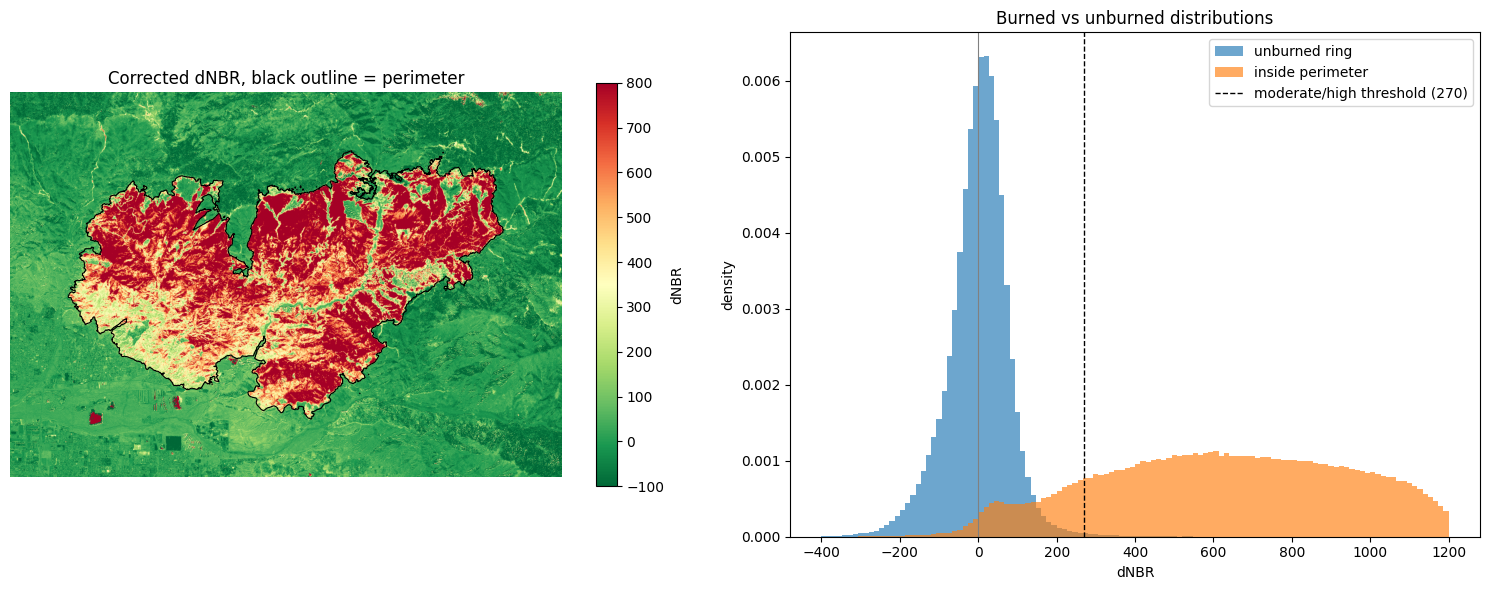

In [8]:
# Cell 8 --- NBR, dNBR, offset correction. All math via debrisflow.severity.

import numpy as np
import matplotlib.pyplot as plt
from rasterio.features import rasterize

tr = rasters['pre']['transform']
sev_shape = rasters['pre']['nir'].shape          # (rows, cols) of the 20 m grid

for phase, d in SCENES.items():
    print(f'needs_baseline_offset({d}) = {severity.needs_baseline_offset(d)}')

# --- NBR and uncorrected dNBR --------------------------------------------------
nbr_pre = severity.nbr(rasters['pre']['nir'], rasters['pre']['swir'])
nbr_post = severity.nbr(rasters['post']['nir'], rasters['post']['swir'])
dnbr_raw = severity.dnbr(nbr_pre, nbr_post)          # offset defaults to 0.0

# --- Masks ---------------------------------------------------------------------
perim_geom = perim_utm.geometry.iloc[0]              # perimeter in the working UTM CRS


def rast20(geom):
    return rasterize([(geom, 1)], out_shape=sev_shape, transform=tr,
                     fill=0, dtype='uint8').astype(bool)


burn_mask = rast20(perim_geom)
ring_geom = perim_geom.buffer(3000).difference(perim_geom.buffer(500))
ring_mask = rast20(ring_geom)

GOOD_SCL = [4, 5]        # 4 = vegetation, 5 = not-vegetated / bare soil
scl_ok = (np.isin(rasters['pre']['scl'], GOOD_SCL) &
          np.isin(rasters['post']['scl'], GOOD_SCL))

physical = np.ones(sev_shape, dtype=bool)
for arr in [rasters[p][band] for p in ('pre', 'post') for band in ('nir', 'swir')]:
    physical &= (arr <= 1.0)
dnbr_finite = np.isfinite(dnbr_raw)

unburned_mask = ring_mask & scl_ok & physical & dnbr_finite

print('\n--- Unburned reference mask ---')
print(f'ring (geometry only)      : {ring_mask.sum():>9,} px')
print(f'  after SCL 4/5 both dates: {(ring_mask & scl_ok).sum():>9,} px')
print(f'  after reflectance <= 1  : {(ring_mask & scl_ok & physical).sum():>9,} px')
print(f'  after finite            : {unburned_mask.sum():>9,} px'
      f'  ({unburned_mask.sum() / max(ring_mask.sum(), 1):.1%} of ring retained)')

bright = (~physical) & dnbr_finite
print(f'\nreflectance > 1.0 pixels  : {bright.sum():,} total, '
      f'{(bright & burn_mask).sum():,} inside perimeter, '
      f'{(bright & ring_mask).sum():,} inside ring')
if unburned_mask.sum() < 10000:
    print('\nWARNING: unburned sample is small. The offset may be unstable.')

# --- Offset and correction -----------------------------------------------------
offset = severity.dnbr_offset(dnbr_raw, unburned_mask)
dnbr_corrected = severity.dnbr(nbr_pre, nbr_post, offset=offset)

print('\n--- Offset correction ---')
print(f'dNBR offset               : {offset:.2f}')
print(f'raw mean over ring        : {np.nanmean(dnbr_raw[unburned_mask]):.2f}')
print(f'corrected mean over ring  : {np.nanmean(dnbr_corrected[unburned_mask]):.2f}  (should be ~0)')

# --- Severity inside the burn perimeter ----------------------------------------
dnbr_in_burn = dnbr_corrected[burn_mask & dnbr_finite]
sev = severity.severity_class(dnbr_corrected)
mh20 = severity.moderate_high_mask(dnbr_corrected)   # moderate-or-high, 20 m grid

print('\n--- Severity inside the perimeter ---')
print(f'pixels                    : {dnbr_in_burn.size:,}')
print(f'mean dNBR                 : {np.nanmean(dnbr_in_burn):.1f}')
print(f'median dNBR               : {np.nanmedian(dnbr_in_burn):.1f}')
print('percentiles 5/25/75/95    : ' +
      ', '.join(f'{np.nanpercentile(dnbr_in_burn, q):.0f}' for q in (5, 25, 75, 95)))
for cls_name, cls_val in (('unburned/low', 0), ('moderate', 1), ('high', 2)):
    n = int((sev[burn_mask] == cls_val).sum())
    print(f'  {cls_name:14s}          : {n:>9,} px  ({n / max(dnbr_in_burn.size, 1):6.1%})')
print(f'moderate-or-high fraction : {mh20[burn_mask].mean():.1%}')

# --- Look at it ----------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
im = ax[0].imshow(np.where(dnbr_finite, dnbr_corrected, np.nan), cmap='RdYlGn_r', vmin=-100, vmax=800)
ax[0].contour(burn_mask.astype(float), levels=[0.5], colors='black', linewidths=0.8)
ax[0].set_title('Corrected dNBR, black outline = perimeter')
ax[0].axis('off')
fig.colorbar(im, ax=ax[0], shrink=0.8, label='dNBR')

ax[1].hist(dnbr_corrected[unburned_mask], bins=120, range=(-400, 1200),
           alpha=0.65, label='unburned ring', density=True)
ax[1].hist(dnbr_in_burn, bins=120, range=(-400, 1200),
           alpha=0.65, label='inside perimeter', density=True)
ax[1].axvline(270, color='k', ls='--', lw=1, label='moderate/high threshold (270)')
ax[1].axvline(0, color='gray', lw=0.8)
ax[1].set_xlabel('dNBR'); ax[1].set_ylabel('density'); ax[1].legend()
ax[1].set_title('Burned vs unburned distributions')
plt.tight_layout(); plt.show()

## Cell 9: Write the dNBR product and its provenance

Saves dNBR, severity class and the valid mask as one 3-band GeoTIFF, and writes `provenance_dnbr.json` with the scenes, the offset, the unburned sample size and the rules that picked it. That file is what makes the hazard numbers defensible months from now.

In [9]:
# Cell 9 --- write the dNBR product and its provenance

DNBR_PATH = SEV_DIR / f"{CONFIG['fire_id']}_dnbr_20m.tif"

dnbr_profile = {
    'driver': 'GTiff', 'height': sev_shape[0], 'width': sev_shape[1], 'count': 3,
    'dtype': 'float32', 'nodata': np.nan, 'crs': TARGET_CRS, 'transform': tr,
    'compress': 'deflate', 'tiled': True, 'blockxsize': 256, 'blockysize': 256,
}

with rasterio.open(DNBR_PATH, 'w', **dnbr_profile) as dst:
    dst.write(dnbr_corrected.astype('float32'), 1)
    dst.write(sev.astype('float32'), 2)
    dst.write(dnbr_finite.astype('float32'), 3)
    dst.set_band_description(1, 'dNBR_offset_corrected')
    dst.set_band_description(2, 'severity_class_0low_1mod_2high_neg1nan')
    dst.set_band_description(3, 'valid_mask')
    dst.update_tags(
        fire=f"{CONFIG['display_name']} {CONFIG['target_year']}",
        perimeter_source=PERIM_SOURCE,
        pre_scene=SCENES['pre'], post_scene=SCENES['post'],
        dnbr_offset=f'{offset:.4f}',
        moderate_high_threshold='270',
    )
print(f'Saved -> {DNBR_PATH}')

prov = dict(provenance)
prov['dnbr'] = {
    'offset': float(offset),
    'offset_units': 'scaled dNBR (x1000)',
    'unburned_sample_px': int(unburned_mask.sum()),
    'unburned_rule': {
        'ring_inner_m': 500, 'ring_outer_m': 3000,
        'scl_classes': GOOD_SCL, 'scl_both_dates': True,
        'max_reflectance': 1.0,
    },
    'ring_retained_fraction': float(unburned_mask.sum() / max(int(ring_mask.sum()), 1)),
    'moderate_high_threshold': 270,
    'perimeter_stats': {
        'pixels': int(dnbr_in_burn.size),
        'mean_dnbr': float(np.nanmean(dnbr_in_burn)),
        'median_dnbr': float(np.nanmedian(dnbr_in_burn)),
        'moderate_high_fraction': float(mh20[burn_mask].mean()),
    },
    'perimeter_source': f'{PERIM_SOURCE}, where: {PERIM_WHERE}',
    'perimeter_acres': float(acres),
}

PROV_PATH = SEV_DIR / 'provenance_dnbr.json'
with open(PROV_PATH, 'w') as f:
    json.dump(prov, f, indent=2)
print(f'Saved -> {PROV_PATH}')
print(json.dumps(prov['dnbr'], indent=2))

Saved -> /content/drive/MyDrive/postfire-debris-flow/line_2024/severity/line_2024_dnbr_20m.tif
Saved -> /content/drive/MyDrive/postfire-debris-flow/line_2024/severity/provenance_dnbr.json
{
  "offset": -4.773566246032715,
  "offset_units": "scaled dNBR (x1000)",
  "unburned_sample_px": 454953,
  "unburned_rule": {
    "ring_inner_m": 500,
    "ring_outer_m": 3000,
    "scl_classes": [
      4,
      5
    ],
    "scl_both_dates": true,
    "max_reflectance": 1.0
  },
  "ring_retained_fraction": 0.9798707298529611,
  "moderate_high_threshold": 270,
  "perimeter_stats": {
    "pixels": 449011,
    "mean_dnbr": 628.9225463867188,
    "median_dnbr": 633.4733276367188,
    "moderate_high_fraction": 0.8502152508513154
  },
  "perimeter_source": "CAL FIRE FRAP, all perimeters, where: UPPER(FIRE_NAME) LIKE '%LINE%' AND YEAR_ = 2024",
  "perimeter_acres": 44386.99109162288
}


## Cell 10: Fetch, reproject, and mosaic the 3DEP 10 m DEM

Queries `3dep-seamless` for the 10 m product with an 8 km buffer, so watersheds that start outside the fire are captured whole. Tiles are reprojected on the fly to the working UTM zone. The grid is snapped to a 20 m multiple so the 10 m terrain grid nests exactly inside the 20 m severity grid.

**What to check:** `NaN inside burn` must be 0. A DEM hole inside the burn breaks D8 routing straight through it. `Severity grid nests` must be True.

DEM grid   : EPSG:32611, 10 m
Bounds     : (np.float64(474920.0), np.float64(3764360.0), np.float64(513560.0), np.float64(3794320.0))
Size       : 3864 x 2996 px
Severity grid nests: True

3DEP items found: 2
  n35w118-13  gsd=10
  n35w117-13  gsd=10

DEM shape      : (2996, 3864)
Elevation range: 306.1 to 3313.5 m
NaN cells      : 2,996 (0.0259%)
NaN inside burn: 0  (good)

Saved -> /content/drive/MyDrive/postfire-debris-flow/line_2024/terrain/line_2024_dem_10m.tif


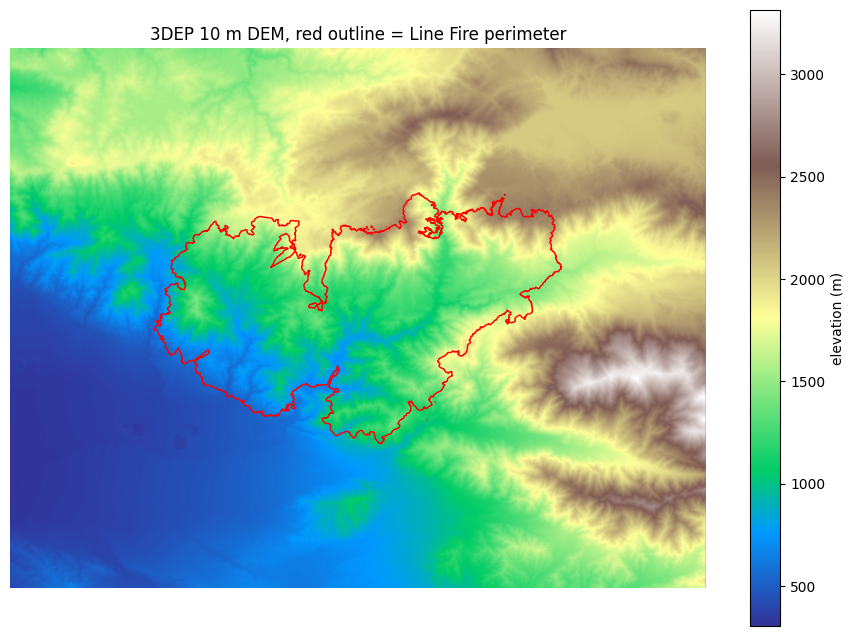

In [10]:
# Cell 10 --- fetch, reproject and mosaic the 3DEP 10 m DEM

import numpy as np
import rasterio
from rasterio.merge import merge
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling
from rasterio.warp import transform_bounds
from rasterio.features import rasterize
from shapely.geometry import box as shp_box
import importlib
from debrisflow import terrain
importlib.reload(terrain)

DEM_BUFFER_M = 8000
DEM_RES = 10

# --- Target grid: snapped to 20 m so the 10 m grid nests inside the severity grid
db = transform_bounds('EPSG:4326', TARGET_CRS, *perimeter.total_bounds)
dxmin = np.floor((db[0] - DEM_BUFFER_M) / 20) * 20
dymin = np.floor((db[1] - DEM_BUFFER_M) / 20) * 20
dxmax = np.ceil((db[2] + DEM_BUFFER_M) / 20) * 20
dymax = np.ceil((db[3] + DEM_BUFFER_M) / 20) * 20
DEM_BOUNDS = (dxmin, dymin, dxmax, dymax)

print(f'DEM grid   : {TARGET_CRS}, {DEM_RES} m')
print(f'Bounds     : {DEM_BOUNDS}')
print(f'Size       : {int((dxmax - dxmin) / DEM_RES)} x {int((dymax - dymin) / DEM_RES)} px')
print(f'Severity grid nests: '
      f'{(dxmin % 20 == 0) and (dymin % 20 == 0) and (xmin % 20 == 0) and (ymin % 20 == 0)}\n')

# --- STAC query, filtered to the 10 m product ---------------------------------
dem_aoi = gpd.GeoSeries([shp_box(*DEM_BOUNDS)], crs=TARGET_CRS).to_crs('EPSG:4326').iloc[0]

dem_items = list(catalog.search(
    collections=['3dep-seamless'],
    intersects=json.loads(gpd.GeoSeries([dem_aoi], crs='EPSG:4326').to_json())
                   ['features'][0]['geometry'],
    query={'gsd': {'eq': DEM_RES}},
).items())

print(f'3DEP items found: {len(dem_items)}')
for it in dem_items:
    print(f'  {it.id}  gsd={it.properties.get("gsd")}')
if not dem_items:
    raise RuntimeError('No 10 m 3DEP items returned. Check the gsd filter.')

# --- Reproject each tile on the fly, then mosaic -------------------------------
srcs, vrts = [], []
try:
    for it in dem_items:
        src = rasterio.open(it.assets['data'].href)
        srcs.append(src)
        vrts.append(WarpedVRT(src, crs=TARGET_CRS, resampling=Resampling.bilinear))
    dem, dem_transform = merge(vrts, bounds=DEM_BOUNDS, res=(DEM_RES, DEM_RES),
                               resampling=Resampling.bilinear)
finally:
    for v in vrts:
        v.close()
    for s in srcs:
        s.close()

dem = dem[0].astype('float32')
dem[dem < -1000] = np.nan            # 3DEP uses a large negative nodata sentinel

print(f'\nDEM shape      : {dem.shape}')
print(f'Elevation range: {np.nanmin(dem):.1f} to {np.nanmax(dem):.1f} m')
print(f'NaN cells      : {np.isnan(dem).sum():,} ({np.isnan(dem).mean():.4%})')

# --- Nodata inside the burn area would break routing ---------------------------
burn_dem = rasterize([(perim_geom, 1)], out_shape=dem.shape, transform=dem_transform,
                     fill=0, dtype='uint8').astype(bool)
dem_holes = int(np.isnan(dem)[burn_dem].sum())
print(f'NaN inside burn: {dem_holes:,}' + ('  <-- PROBLEM' if dem_holes else '  (good)'))

# --- Save ----------------------------------------------------------------------
TER_DIR = FIRE_DIR / 'terrain'
DEM_PATH = TER_DIR / f"{CONFIG['fire_id']}_dem_10m.tif"
dem_profile = {
    'driver': 'GTiff', 'height': dem.shape[0], 'width': dem.shape[1], 'count': 1,
    'dtype': 'float32', 'nodata': np.nan, 'crs': TARGET_CRS,
    'transform': dem_transform, 'compress': 'deflate', 'tiled': True,
}
with rasterio.open(DEM_PATH, 'w', **dem_profile) as dst:
    dst.write(dem, 1)
    dst.set_band_description(1, 'elevation_m_3dep_10m')
    dst.update_tags(source='USGS 3DEP seamless 1/3 arc-second via Planetary Computer',
                    buffer_m=str(DEM_BUFFER_M))
print(f'\nSaved -> {DEM_PATH}')

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(dem, cmap='terrain')
ax.contour(burn_dem.astype(float), levels=[0.5], colors='red', linewidths=1.0)
ax.set_title(f"3DEP 10 m DEM, red outline = {CONFIG['display_name']} perimeter")
ax.axis('off')
fig.colorbar(im, ax=ax, shrink=0.8, label='elevation (m)')
plt.tight_layout(); plt.show()

## Cell 11: DEM conditioning, slope, and flow routing

1. **Conditioning:** fills pits, depressions and flats so flow accumulation does not dead-end.
2. **Routing:** D8 flow direction and accumulation on the *conditioned* DEM.
3. **Slope:** Horn slope and the steep mask on the *raw* DEM, because filling flattens real slopes.

**pysheds is pinned to 0.5.** Unpinned, a Python 3.13 Colab runtime installed 0.4, which crashes under numpy 2 with "`nodata` value not representable in dtype of array". The tripwire stops the cell if the wrong version is loaded. If it trips, use **Runtime > Restart session** and run from Cell 1.

**What to check**
* pysheds version reads 0.5.
* Cells altered: a small fraction of a percent.
* Steep in burn is the ceiling for T. Bridge reference: mean slope 22.5 degrees over the extent, 83.0% of the burn steep.
* The accumulation panel shows a continuous branching network.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 997.8 kB/s eta 0:00:00
pysheds version: 0.5   numpy: 2.1.3
pysheds grid   : (2996, 3864), crs set: True

Conditioning (pits -> depressions -> flats)...
  cells altered : 232,091 (2.005%)
  max raise     : 135.822 m

D8 flow direction and accumulation...
  max accumulation: 5,816,755 cells (581.7 km2)

Horn slope from the RAW DEM...
  slope range   : 0.0 to 75.0 degrees
  mean slope    : 19.0 degrees
  NaN (edges)   : 16,710
  steep >= 23   : 4,695,267 px (40.6% of valid)
  steep in burn : 71.0% of the burn area

M1 calibration range in cells: 1,000 to 80,000
cells above 0.1 km2 threshold: 260,008


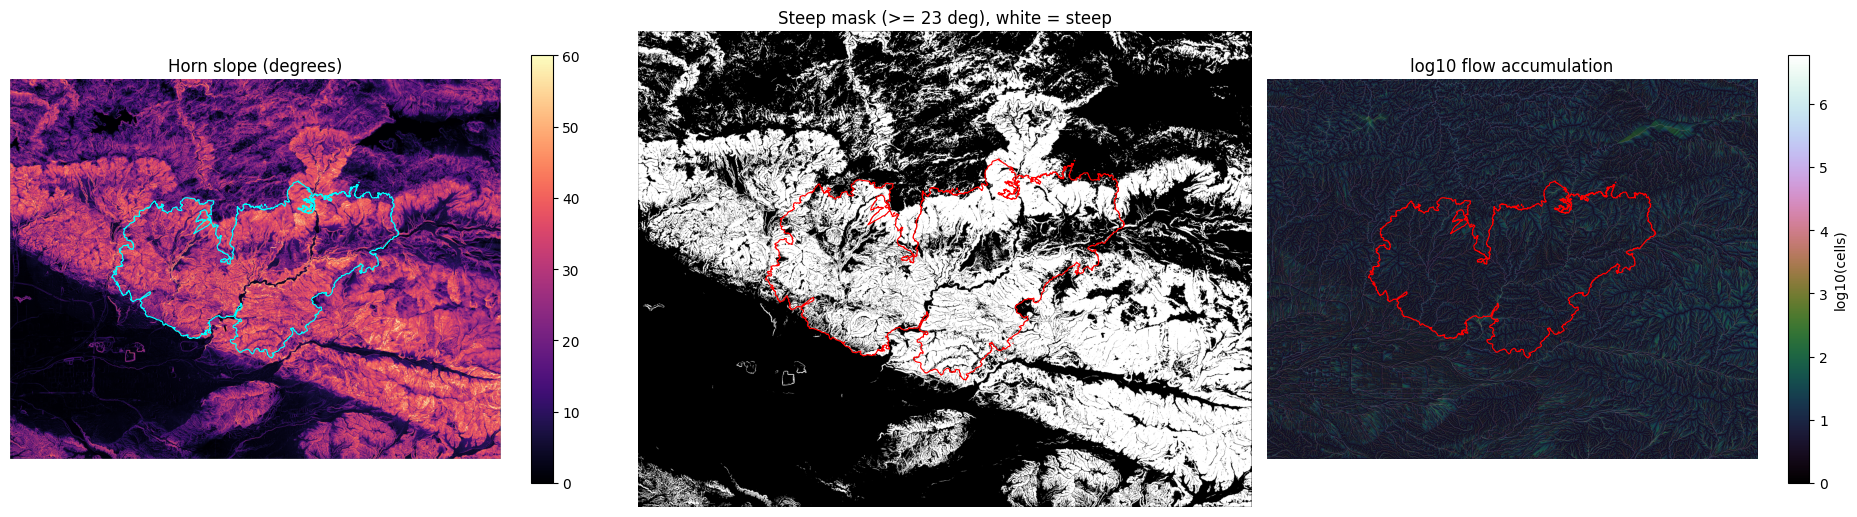

In [11]:
# Cell 11 --- condition, route, and measure slope

!pip install -q "pysheds==0.5"

import numpy as np
import matplotlib.pyplot as plt
import importlib
from importlib.metadata import version as pkg_version

# --- Tripwire: fail loudly if the wrong pysheds is loaded ----------------------
PYSHEDS_VERSION = pkg_version('pysheds')
print(f'pysheds version: {PYSHEDS_VERSION}   numpy: {np.__version__}')
assert PYSHEDS_VERSION == '0.5', (
    f'pysheds {PYSHEDS_VERSION} loaded, expected 0.5. '
    'Use Runtime > Restart session, then run from Cell 1.')

from pysheds.grid import Grid
from debrisflow import terrain          # importing terrain also applies the np.in1d shim
importlib.reload(terrain)

# --- Load the DEM into pysheds -------------------------------------------------
grid = Grid.from_raster(str(DEM_PATH))
dem_raster = grid.read_raster(str(DEM_PATH))
print(f'pysheds grid   : {grid.shape}, crs set: {grid.crs is not None}')

# --- Routing surface: conditioned ---------------------------------------------
print('\nConditioning (pits -> depressions -> flats)...')
conditioned = terrain.condition_dem(grid, dem_raster)
changed = np.asarray(conditioned) - np.asarray(dem_raster)
n_changed = int((np.abs(changed) > 1e-6).sum())
print(f'  cells altered : {n_changed:,} ({n_changed / changed.size:.3%})')
print(f'  max raise     : {np.nanmax(changed):.3f} m')

print('\nD8 flow direction and accumulation...')
fdir, acc = terrain.flow_grids(grid, conditioned)
acc_arr = np.asarray(acc)
print(f'  max accumulation: {acc_arr.max():,.0f} cells '
      f'({acc_arr.max() * 100 / 1e6:,.1f} km2)')

# --- Measurement surface: RAW dem ---------------------------------------------
print('\nHorn slope from the RAW DEM...')
slope = terrain.slope_degrees(dem, cellsize_m=DEM_RES)
steep = terrain.steep_mask(slope, threshold=23.0)

valid_slope = np.isfinite(slope)
print(f'  slope range   : {np.nanmin(slope):.1f} to {np.nanmax(slope):.1f} degrees')
print(f'  mean slope    : {np.nanmean(slope):.1f} degrees')
print(f'  NaN (edges)   : {(~valid_slope).sum():,}')
print(f'  steep >= 23   : {steep.sum():,} px ({steep[valid_slope].mean():.1%} of valid)')
print(f'  steep in burn : {steep[burn_dem].mean():.1%} of the burn area')

# --- Sanity: does accumulation trace a real drainage network? ------------------
min_cells = terrain.cells_for_area(0.1, cellsize_m=DEM_RES)
max_cells = terrain.cells_for_area(8.0, cellsize_m=DEM_RES)
print(f'\nM1 calibration range in cells: {min_cells:,.0f} to {max_cells:,.0f}')
print(f'cells above 0.1 km2 threshold: {(acc_arr >= min_cells).sum():,}')

fig, ax = plt.subplots(1, 3, figsize=(19, 6))
im0 = ax[0].imshow(slope, cmap='magma', vmin=0, vmax=60)
ax[0].contour(burn_dem.astype(float), levels=[0.5], colors='cyan', linewidths=0.8)
ax[0].set_title('Horn slope (degrees)'); ax[0].axis('off')
fig.colorbar(im0, ax=ax[0], shrink=0.75)

ax[1].imshow(steep, cmap='gray')
ax[1].contour(burn_dem.astype(float), levels=[0.5], colors='red', linewidths=0.8)
ax[1].set_title('Steep mask (>= 23 deg), white = steep'); ax[1].axis('off')

im2 = ax[2].imshow(np.log10(acc_arr + 1), cmap='cubehelix')
ax[2].contour(burn_dem.astype(float), levels=[0.5], colors='red', linewidths=0.8)
ax[2].set_title('log10 flow accumulation'); ax[2].axis('off')
fig.colorbar(im2, ax=ax[2], shrink=0.75, label='log10(cells)')
plt.tight_layout(); plt.show()

## Cell 12: Delineate basins

Traces the drainage network into non-overlapping basin polygons. Outlets are limited to the perimeter plus 2 km, but basins can reach into the 8 km DEM buffer to capture their whole upstream area. A basin is kept if it touches the burn at all; how much it overlaps is recorded, not used to filter.

**What to check:** a few hundred basins for a fire this size (thousands means the accumulation threshold is too low), and a jigsaw of canyon-shaped pieces on the map. Blank valley floors are expected: trunk drainages too large to be outlets. Bridge reference: 237 basins, median 0.379 km².

Outlet region: 3,366,225 cells (337 km2)
Delineating (one pass over the sorted grid, this takes a minute)...


  basins found : 301
  touching burn: 171

  area km2      : min 0.102, median 0.532, max 8.00
  extrapolations: 0 of 171 outside 0.1-8 km2
  fully burned  : 95
  >50% burned   : 135
  total area    : 249 km2

Polygonised: 171 basin polygons
Saved -> /content/drive/MyDrive/postfire-debris-flow/line_2024/terrain/line_2024_basins.geojson
Saved -> /content/drive/MyDrive/postfire-debris-flow/line_2024/terrain/line_2024_basin_labels_10m.tif


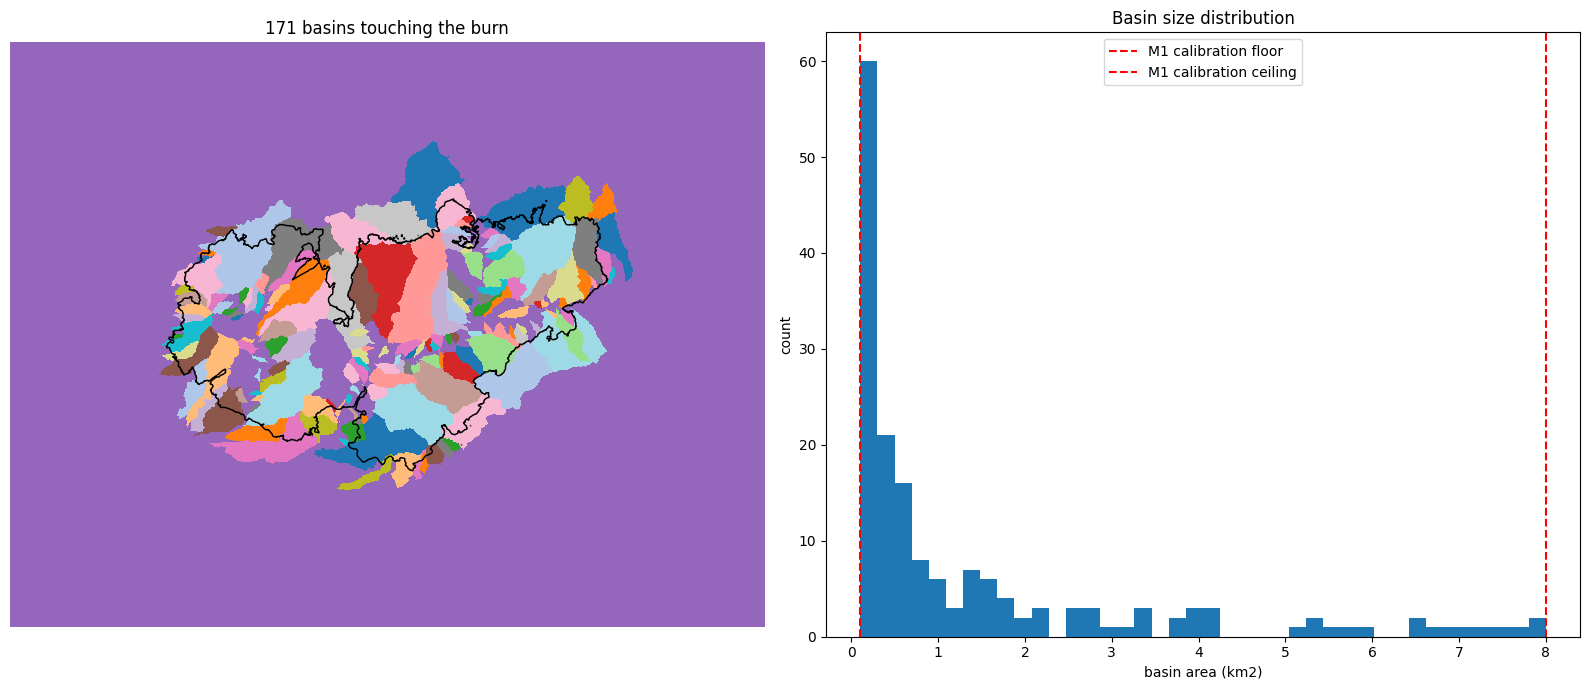

In [12]:
# Cell 12 --- delineate non-overlapping basins

import numpy as np
import geopandas as gpd
from rasterio import features
from shapely.geometry import shape as shp_shape
from debrisflow import basins as basins_mod
importlib.reload(basins_mod)

OUTLET_BUFFER_M = 2000

region = features.rasterize(
    [(perim_geom.buffer(OUTLET_BUFFER_M), 1)],
    out_shape=dem.shape, transform=dem_transform, fill=0, dtype='uint8').astype(bool)
print(f'Outlet region: {region.sum():,} cells ({region.sum() * 100 / 1e6:,.0f} km2)')

fdir_arr = np.asarray(fdir)
acc_arr = np.asarray(acc)

print('Delineating (one pass over the sorted grid, this takes a minute)...')
labels, records = basins_mod.delineate(
    fdir_arr, acc_arr,
    min_cells=int(min_cells), max_cells=int(max_cells),
    region_mask=region)
print(f'  basins found : {len(records):,}')

attrs = basins_mod.basin_attributes(labels, records, burn_dem, cellsize_m=DEM_RES)
burned = [a for a in attrs if a['overlap_fraction'] > 0]
print(f'  touching burn: {len(burned):,}')

basin_areas = np.array([a['area_km2'] for a in burned])
overlaps = np.array([a['overlap_fraction'] for a in burned])
n_extrap = sum(not a['in_calibration_range'] for a in burned)
print(f'\n  area km2      : min {basin_areas.min():.3f}, median {np.median(basin_areas):.3f}, '
      f'max {basin_areas.max():.2f}')
print(f'  extrapolations: {n_extrap:,} of {len(burned):,} outside 0.1-8 km2')
print(f'  fully burned  : {(overlaps > 0.99).sum():,}')
print(f'  >50% burned   : {(overlaps > 0.5).sum():,}')
print(f'  total area    : {basin_areas.sum():,.0f} km2')

# --- Polygonise ---------------------------------------------------------------
keep = {a['id'] for a in burned}
by_id = {a['id']: a for a in burned}
geoms, ids = [], []
for geom, val in features.shapes(labels, mask=labels > 0, transform=dem_transform):
    v = int(val)
    if v in keep:
        geoms.append(shp_shape(geom))
        ids.append(v)

gdf = gpd.GeoDataFrame(
    [{k: v for k, v in by_id[i].items() if k != 'geometry'} for i in ids],
    geometry=geoms, crs=TARGET_CRS)
gdf = gdf.dissolve(by='id', as_index=False, aggfunc='first')
print(f'\nPolygonised: {len(gdf)} basin polygons')

BASIN_PATH = TER_DIR / f"{CONFIG['fire_id']}_basins.geojson"
gdf.to_file(BASIN_PATH, driver='GeoJSON')
print(f'Saved -> {BASIN_PATH}')

LABEL_PATH = TER_DIR / f"{CONFIG['fire_id']}_basin_labels_10m.tif"
lab_profile = dict(dem_profile, dtype='int32', nodata=0, count=1)
with rasterio.open(LABEL_PATH, 'w', **lab_profile) as dst:
    dst.write(np.where(np.isin(labels, list(keep)), labels, 0).astype('int32'), 1)
    dst.set_band_description(1, 'basin_id')
print(f'Saved -> {LABEL_PATH}')

# --- Look at it ---------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(16, 7))
shown = np.where(np.isin(labels, list(keep)), labels, 0).astype(float)
shown[shown == 0] = np.nan
rng = np.random.default_rng(1)
ax[0].imshow(rng.permutation(int(labels.max()) + 2)[np.nan_to_num(shown).astype(int)],
             cmap='tab20', interpolation='nearest')
ax[0].contour(burn_dem.astype(float), levels=[0.5], colors='black', linewidths=1.0)
ax[0].set_title(f'{len(burned)} basins touching the burn'); ax[0].axis('off')

ax[1].hist(basin_areas, bins=40)
ax[1].axvline(0.1, color='r', ls='--', label='M1 calibration floor')
ax[1].axvline(8.0, color='r', ls='--', label='M1 calibration ceiling')
ax[1].set_xlabel('basin area (km2)'); ax[1].set_ylabel('count'); ax[1].legend()
ax[1].set_title('Basin size distribution')
plt.tight_layout(); plt.show()

## Cell 13: Align severity to the terrain grid, then compute T and F

Severity is 20 m, terrain and basins are 10 m. Severity is expanded to 10 m by 2x2 block replication (each 20 m pixel becomes four identical 10 m pixels, no interpolation), then per basin:
* **T** = fraction of the basin that is both steep (>= 23°) and moderate-or-high severity. An intersection, not a product.
* **F** = mean dNBR / 1000.

**What to check**
* **Severity coverage:** basins reach up to 8 km out but severity only 3 km. Uncovered area counts as unburned and drags T down. If the cell says "Widespread", rerun Cell 7 with a larger `BUFFER_M`.
* **T vs F scatter:** they should rise together.
* Bridge reference: 87.6% of the burn inside some basin.

severity origin offset in DEM cells: row 500.0, col 500.0
severity expanded to (2996, 3864), valid over 49.4% of the DEM extent

burn area inside some basin : 91.5%
burn area unassigned        : 8.5%   (trunk canyons above 8 km2)

--- Severity coverage per basin ---
fully covered (>= 0.999)   : 171 of 171
below 0.99                 : 0
below 0.90                 : 0
worst                      : 1.000

>>> Localised. Flag these basins rather than re-reading imagery.

--- T (steep AND moderate/high severity) ---
count    171.000
mean       0.475
std        0.288
min        0.000
25%        0.244
50%        0.502
75%        0.725
max        0.916

--- F (mean dNBR / 1000) ---
count    171.000
mean       0.483
std        0.266
min       -0.060
25%        0.287
50%        0.528
75%        0.686
max        0.998

Saved -> /content/drive/MyDrive/postfire-debris-flow/line_2024/terrain/line_2024_basins_TF.geojson


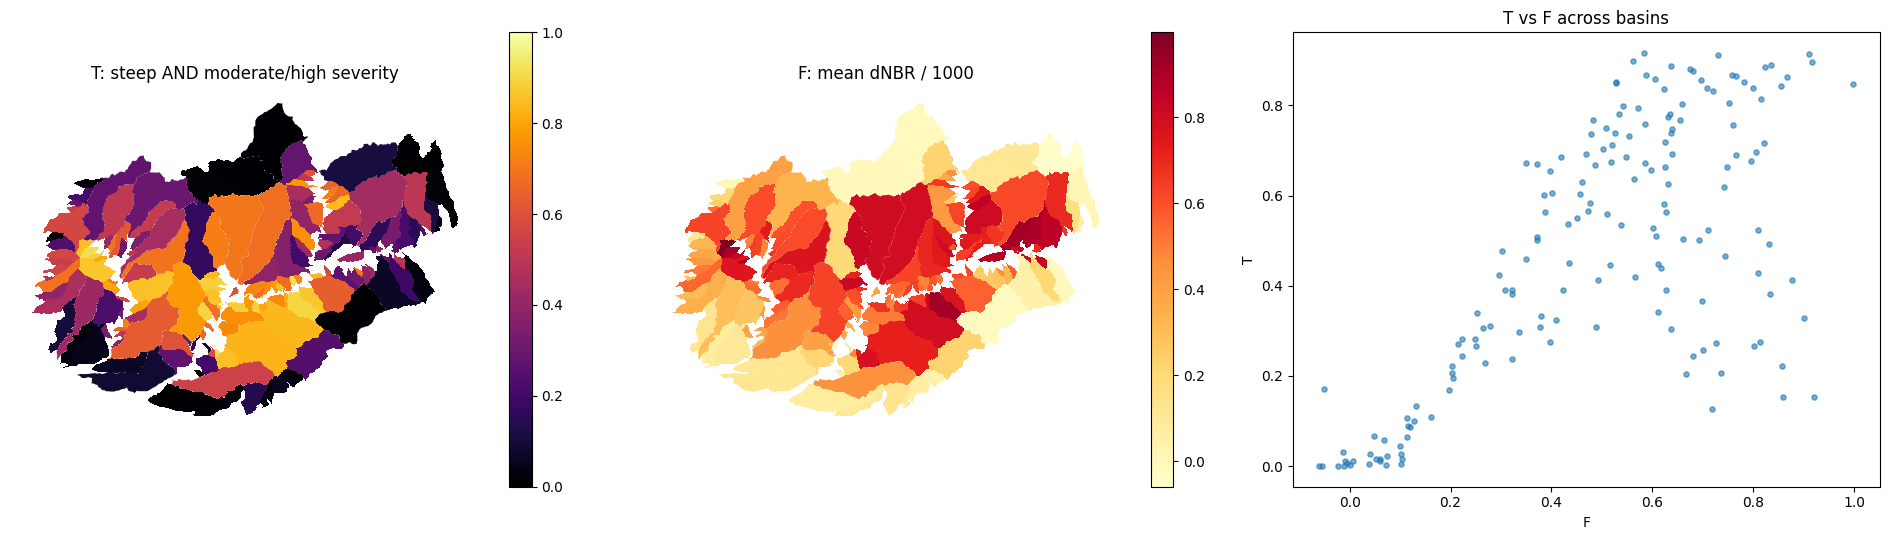

In [13]:
# Cell 13 --- expand severity to 10 m, measure coverage, compute T and F

import numpy as np
import pandas as pd
from scipy import ndimage

# --- Confirm the grids nest, then expand ---------------------------------------
col_off = (tr.c - dem_transform.c) / DEM_RES
row_off = (dem_transform.f - tr.f) / DEM_RES
print(f'severity origin offset in DEM cells: row {row_off}, col {col_off}')
assert float(col_off).is_integer() and float(row_off).is_integer(), \
    'grids do not nest; severity cannot be block-expanded'
row_off, col_off = int(row_off), int(col_off)


def expand_to_dem(arr20, fill=np.nan):
    """Block-replicate a 20 m array onto the 10 m DEM grid at the correct offset."""
    big = np.repeat(np.repeat(arr20, 2, axis=0), 2, axis=1)
    out = np.full(dem.shape, fill, dtype='float32')
    r1 = min(row_off + big.shape[0], dem.shape[0])
    c1 = min(col_off + big.shape[1], dem.shape[1])
    out[row_off:r1, col_off:c1] = big[:r1 - row_off, :c1 - col_off]
    return out


dnbr10 = expand_to_dem(dnbr_corrected)
sev_valid = np.isfinite(dnbr10)
mh10 = severity.moderate_high_mask(dnbr10)
print(f'severity expanded to {dnbr10.shape}, valid over {sev_valid.mean():.1%} of the DEM extent')

# --- How much of the burn is inside any basin? ---------------------------------
in_basin = labels > 0
burn_in_basin = (burn_dem & in_basin).sum() / burn_dem.sum()
print(f'\nburn area inside some basin : {burn_in_basin:.1%}')
print(f'burn area unassigned        : {1 - burn_in_basin:.1%}   (trunk canyons above 8 km2)')

# --- Per-basin variables -------------------------------------------------------
slices = ndimage.find_objects(labels)
tf_rows = []
for a in burned:
    bid = a['id']
    sl = slices[bid - 1]
    bmask = labels[sl] == bid
    T_val = terrain.basin_T(steep[sl], mh10[sl], bmask)
    F_val = severity.basin_F(dnbr10[sl], bmask)
    tf_rows.append({**a, 'severity_coverage': float(sev_valid[sl][bmask].mean()),
                    'T': float(T_val), 'F': float(F_val)})
tf_df = pd.DataFrame(tf_rows)

print('\n--- Severity coverage per basin ---')
print(f'fully covered (>= 0.999)   : {(tf_df.severity_coverage >= 0.999).sum():,} of {len(tf_df):,}')
print(f'below 0.99                 : {(tf_df.severity_coverage < 0.99).sum():,}')
print(f'below 0.90                 : {(tf_df.severity_coverage < 0.90).sum():,}')
print(f'worst                      : {tf_df.severity_coverage.min():.3f}')
if (tf_df.severity_coverage < 0.99).sum() > 20:
    print('\n>>> Widespread. Rerun Cell 7 with BUFFER_M = 8000 to match the DEM extent.')
else:
    print('\n>>> Localised. Flag these basins rather than re-reading imagery.')

print('\n--- T (steep AND moderate/high severity) ---')
print(tf_df['T'].describe().round(3).to_string())
print('\n--- F (mean dNBR / 1000) ---')
print(tf_df['F'].describe().round(3).to_string())

# --- Attach to the polygons and save ------------------------------------------
gdf_v = gdf.merge(tf_df[['id', 'severity_coverage', 'T', 'F']], on='id', how='left')
VAR_PATH = TER_DIR / f"{CONFIG['fire_id']}_basins_TF.geojson"
gdf_v.to_file(VAR_PATH, driver='GeoJSON')
print(f'\nSaved -> {VAR_PATH}')

fig, ax = plt.subplots(1, 3, figsize=(19, 5.5))
gdf_v.plot(column='T', ax=ax[0], legend=True, cmap='inferno', vmin=0, vmax=1)
ax[0].set_title('T: steep AND moderate/high severity'); ax[0].axis('off')
gdf_v.plot(column='F', ax=ax[1], legend=True, cmap='YlOrRd')
ax[1].set_title('F: mean dNBR / 1000'); ax[1].axis('off')
ax[2].scatter(tf_df['F'], tf_df['T'], s=14, alpha=0.6)
ax[2].set_xlabel('F'); ax[2].set_ylabel('T'); ax[2].set_title('T vs F across basins')
plt.tight_layout(); plt.show()

## Cell 14: Fetch STATSGO polygons and compute S

Queries USDA Soil Data Access for STATSGO map units (`gsmmupolygon`, which the convenient SDA helpers skip) and the surface-horizon KF factor (`kffact`). Null KF values (rock outcrop, water) are dropped and the area renormalised, not zeroed.

**What to check**
* Distinct S values: a few dozen. Every basin unique would mean the aggregation failed, since STATSGO is too coarse for that.
* NaN S must be 0. The model cannot run a basin with no soil data.
* A `JSONDecodeError` from SDA usually means retry, not a bug.

Checking SDA...
[['US', 'United States']]

Query extent (WGS84): [-117.1898, 34.0832, -116.9261, 34.2443]
[try ] gsmmupolygon / mupolygongeo: 26 polygon(s)

Matched via: gsmmupolygon / mupolygongeo
STATSGO polygons: 26, distinct mukeys: 9

Horizon rows returned: 331
Map units with a KF  : 8 of 9
  mukey     657964 -> no KF (rock, water or missing)
  mukey     660451 -> KF 0.2917, coverage 0.88
  mukey     660474 -> KF 0.2432, coverage 0.81
  mukey     660494 -> KF 0.2415, coverage 0.88
  mukey     660495 -> KF 0.2438, coverage 0.94
  mukey     660496 -> KF 0.2411, coverage 0.84
  mukey     660497 -> KF 0.2198, coverage 0.99
  mukey     660499 -> KF 0.2628, coverage 0.85

Intersection pieces: 530

--- S (area-weighted surface KF) ---
count    171.0000
mean       0.2470
std        0.0069
min        0.2392
25%        0.2438
50%        0.2440
75%        0.2445
max        0.2628

distinct S values     : 48 across 171 basins
basins flagged low cov: 0
NaN S                 : 0
failing validat

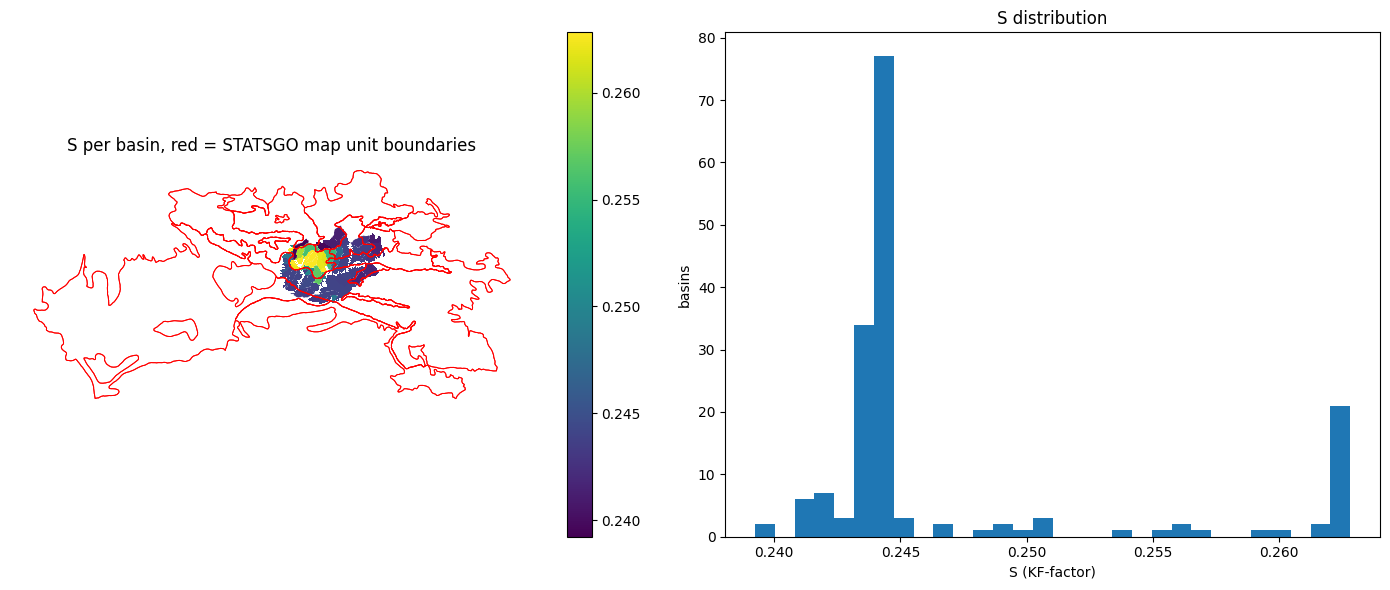

In [14]:
# Cell 14 --- STATSGO spatial query, then S per basin

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely import wkt as shapely_wkt
from shapely.geometry import box as shp_box
from debrisflow import soils
importlib.reload(soils)

print('Checking SDA...')
print(soils.check_sda_connection())

bounds4326 = gdf_v.to_crs('EPSG:4326').total_bounds
aoi_wkt = shp_box(*bounds4326).wkt
print(f'\nQuery extent (WGS84): {np.round(bounds4326, 4).tolist()}')

# gsmmupolygon is the STATSGO geometry table. Column naming has varied.
SPATIAL_SQL = [
    ('gsmmupolygon / mupolygongeo',
     'SELECT G.mukey, G.mupolygongeo.STAsText() AS geom '
     'FROM gsmmupolygon AS G '
     f"WHERE G.mupolygongeo.STIntersects(geometry::STGeomFromText('{aoi_wkt}', 4326)) = 1"),
    ('gsmmupolygon / geom',
     'SELECT G.mukey, G.geom.STAsText() AS geom '
     'FROM gsmmupolygon AS G '
     f"WHERE G.geom.STIntersects(geometry::STGeomFromText('{aoi_wkt}', 4326)) = 1"),
]

rows_spatial, used_sql = None, None
for sql_label, sql in SPATIAL_SQL:
    try:
        res_rows = soils.sda_query(sql)
    except Exception as e:
        print(f'[skip] {sql_label}: {type(e).__name__}: {e}')
        continue
    print(f'[try ] {sql_label}: {len(res_rows) if res_rows else 0} polygon(s)')
    if res_rows:
        rows_spatial, used_sql = res_rows, sql_label
        break
if not rows_spatial:
    raise RuntimeError('No STATSGO polygons returned. Inspect the SQL variants above.')

mu = gpd.GeoDataFrame(
    {'mukey': [str(row[0]) for row in rows_spatial]},
    geometry=[shapely_wkt.loads(row[1]) for row in rows_spatial],
    crs='EPSG:4326').to_crs(TARGET_CRS)
mu = mu[mu.is_valid | mu.buffer(0).is_valid].copy()
mu['geometry'] = mu.geometry.buffer(0)         # repair self-intersections
print(f'\nMatched via: {used_sql}')
print(f'STATSGO polygons: {len(mu)}, distinct mukeys: {mu.mukey.nunique()}')

SOIL_DIR = FIRE_DIR / 'soils'
mu.to_file(SOIL_DIR / 'statsgo_mapunits.geojson', driver='GeoJSON')

# --- Tabular: surface-horizon KF for those map units --------------------------
mukeys = sorted(mu.mukey.unique())
kf_rows = soils.sda_query(soils.kf_by_mapunit_sql(mukeys, dataset='statsgo'))
print(f'\nHorizon rows returned: {len(kf_rows):,}')

kf_lookup = soils.kf_by_mapunit(kf_rows, surface_only=True)
print(f'Map units with a KF  : {len(kf_lookup)} of {len(mukeys)}')
for k in mukeys[:8]:
    v = kf_lookup.get(k)
    print(f'  mukey {k:>10} -> ' + (f'KF {v[0]:.4f}, coverage {v[1]:.2f}'
                                    if v else 'no KF (rock, water or missing)'))

# --- Area-weighted S per basin ------------------------------------------------
inter = gpd.overlay(gdf_v[['id', 'geometry']], mu, how='intersection')
inter['area_m2'] = inter.geometry.area
print(f'\nIntersection pieces: {len(inter):,}')

s_rows = []
for bid, grp in inter.groupby('id'):
    kfs, piece_areas = [], []
    for _, piece in grp.iterrows():
        v = kf_lookup.get(piece['mukey'])
        kfs.append(v[0] if v else np.nan)
        piece_areas.append(piece['area_m2'])
    res = soils.mapunit_to_basin(kfs, piece_areas)
    S_val, cov = res if isinstance(res, tuple) else (res, np.nan)
    s_rows.append({'id': bid, 'S': float(S_val), 'S_coverage': float(cov),
                   'n_mapunits': len(grp),
                   'S_low_coverage': bool(soils.flag_low_coverage(cov)) if cov == cov else True})

s_df = pd.DataFrame(s_rows)
print('\n--- S (area-weighted surface KF) ---')
print(s_df['S'].describe().round(4).to_string())
print(f'\ndistinct S values     : {s_df.S.round(4).nunique()} across {len(s_df)} basins')
print(f'basins flagged low cov: {int(s_df.S_low_coverage.sum())}')
print(f'NaN S                 : {int(s_df.S.isna().sum())}')
print(f'failing validate_kf   : {sum(1 for v in s_df.S.dropna() if not soils.validate_kf(v))}')

gdf_s = gdf_v.merge(s_df, on='id', how='left')
S_PATH = SOIL_DIR / f"{CONFIG['fire_id']}_basins_TFS.geojson"
gdf_s.to_file(S_PATH, driver='GeoJSON')
print(f'\nSaved -> {S_PATH}')

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
gdf_s.plot(column='S', ax=ax[0], legend=True, cmap='viridis')
mu.boundary.plot(ax=ax[0], color='red', linewidth=0.7)
ax[0].set_title('S per basin, red = STATSGO map unit boundaries'); ax[0].axis('off')
ax[1].hist(s_df.S.dropna(), bins=30)
ax[1].set_xlabel('S (KF-factor)'); ax[1].set_ylabel('basins'); ax[1].set_title('S distribution')
plt.tight_layout(); plt.show()

## Cell 15: Score every basin with M1

Runs the M1 likelihood model on every basin:
1. **Probability** of a debris flow under the six USGS 15-minute design storms (12, 16, 20, 24, 32, 40 mm/hr).
2. **Threshold:** the rainfall intensity (mm/hr) at which the probability reaches 50%. This is the number warning systems use.

F is clamped at zero here. A negative basin-mean dNBR means the basin looked slightly greener after the fire, which for edge basins is scene noise around zero, not negative burning.

**What to check:** probability rises with rainfall in every basin (asserted), and high-T basins have low thresholds. Bridge reference: median threshold about 16.4 mm/hr.

Coefficients in use: {'B': -3.63, 'Ct': 0.41, 'Cf': 0.67, 'Cs': 0.7}
Model consumes     : accumulation_mm
Design storms      : [12, 16, 20, 24, 32, 40] mm/hr over 15 min

F clamped to 0 : 8 of 171 basins (min raw F was -0.0597)
  their T max  : 0.172   <-- should be near zero; these basins barely touch the fire

Monotonicity check passed: p rises with rainfall in every basin.

--- Probability by design storm ---
       p_12   p_16   p_20   p_24   p_32   p_40
mean  0.203  0.340  0.485  0.604  0.748  0.818
50%   0.207  0.360  0.546  0.721  0.922  0.982
min   0.042  0.050  0.058  0.068  0.093  0.125
max   0.493  0.764  0.915  0.973  0.997  1.000

--- Fraction of basins at High (p >= 0.6) ---
  12 mm/hr :   0.0%
  16 mm/hr :   8.8%
  20 mm/hr :  43.3%
  24 mm/hr :  64.3%
  32 mm/hr :  74.3%
  40 mm/hr :  80.7%

--- Rainfall threshold for P = 0.5 (mm/hr, 15 min) ---
  basins solved : 171 of 171
  unreachable   : 0
count    171.00
mean      27.85
std       19.43
min       12.09
25%       16.

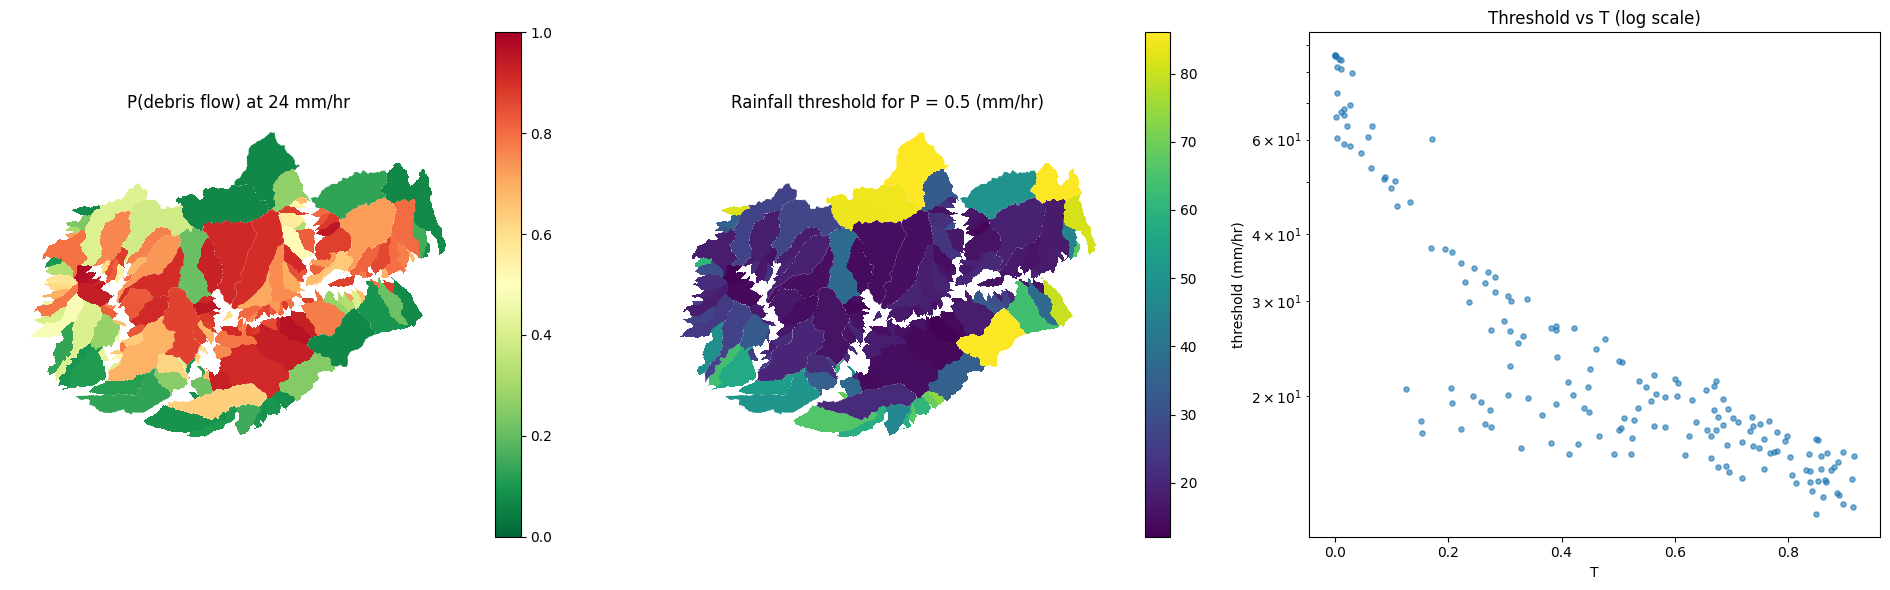

In [15]:
# Cell 15 --- run M1 on every basin

import numpy as np
import pandas as pd
from debrisflow import m1
importlib.reload(m1)

DESIGN_STORMS = [12, 16, 20, 24, 32, 40]      # 15-minute intensities, mm/hr
REFERENCE_STORM = 24
INTENSITY = m1.RainfallConvention.INTENSITY_MM_HR

print(f'Coefficients in use: {m1.M1_PARAMETERS[15]}')
print(f'Model consumes     : {m1.MODEL_CONVENTION.value}')
print(f'Design storms      : {DESIGN_STORMS} mm/hr over 15 min\n')

scores = []
for _, row in gdf_s.iterrows():
    F_raw = float(row['F'])
    F_used = max(F_raw, 0.0)          # clamp in the driver; m1.py stays strict
    bv = m1.BasinVariables(T=float(row['T']), F=F_used, S=float(row['S']))

    rec = {'id': int(row['id']), 'F_raw': F_raw, 'F_used': F_used, 'F_clamped': bool(F_raw < 0.0)}
    for storm in DESIGN_STORMS:
        rec[f'p_{storm}'] = float(m1.likelihood(bv, storm, convention=INTENSITY, duration_min=15))
    try:
        thr = float(m1.accumulation(bv, target_p=0.5, duration_min=15, out_convention=INTENSITY))
    except Exception:
        thr = np.inf                  # cannot reach P = 0.5 at any rainfall
    rec['threshold_mm_hr'] = thr
    rec['hazard_at_ref'] = m1.hazard_class(rec[f'p_{REFERENCE_STORM}'])
    scores.append(rec)

sc = pd.DataFrame(scores)

n_clamped = int(sc.F_clamped.sum())
print(f'F clamped to 0 : {n_clamped} of {len(sc)} basins (min raw F was {sc.F_raw.min():.4f})')
if n_clamped:
    print(f'  their T max  : {gdf_s.set_index("id").loc[sc[sc.F_clamped].id, "T"].max():.3f}'
          '   <-- should be near zero; these basins barely touch the fire')

# --- Monotonicity: p must rise with rainfall for every basin -------------------
pcols = [f'p_{storm}' for storm in DESIGN_STORMS]
assert (sc[pcols].diff(axis=1).iloc[:, 1:] >= -1e-9).all().all(), 'probability decreased with more rainfall'
print('\nMonotonicity check passed: p rises with rainfall in every basin.\n')

print('--- Probability by design storm ---')
print(sc[pcols].describe().loc[['mean', '50%', 'min', 'max']].round(3).to_string())

print('\n--- Fraction of basins at High (p >= 0.6) ---')
for storm in DESIGN_STORMS:
    print(f'  {storm:>2} mm/hr : {(sc[f"p_{storm}"] >= 0.6).mean():6.1%}')

print('\n--- Rainfall threshold for P = 0.5 (mm/hr, 15 min) ---')
thr_finite = sc.threshold_mm_hr[np.isfinite(sc.threshold_mm_hr)]
print(f'  basins solved : {len(thr_finite)} of {len(sc)}')
print(f'  unreachable   : {len(sc) - len(thr_finite)}')
print(thr_finite.describe().round(2).to_string())

print(f'\n--- Hazard class at {REFERENCE_STORM} mm/hr ---')
print(sc.hazard_at_ref.value_counts().to_string())

# --- Attach and save ----------------------------------------------------------
gdf_m = gdf_s.merge(sc, on='id', how='left')
MODEL_DIR = FIRE_DIR / 'model'
SCORED_PATH = MODEL_DIR / f"{CONFIG['fire_id']}_basins_scored.geojson"
gdf_m.drop(columns=['threshold_mm_hr']).assign(
    threshold_mm_hr=gdf_m.threshold_mm_hr.replace([np.inf, -np.inf], None)
).to_file(SCORED_PATH, driver='GeoJSON')
print(f'\nSaved -> {SCORED_PATH}')

fig, ax = plt.subplots(1, 3, figsize=(19, 6))
gdf_m.plot(column=f'p_{REFERENCE_STORM}', ax=ax[0], legend=True, cmap='RdYlGn_r', vmin=0, vmax=1)
ax[0].set_title(f'P(debris flow) at {REFERENCE_STORM} mm/hr'); ax[0].axis('off')

plot_thr = gdf_m.copy()
plot_thr['thr_plot'] = plot_thr.threshold_mm_hr.replace([np.inf, -np.inf], np.nan)
plot_thr.plot(column='thr_plot', ax=ax[1], legend=True, cmap='viridis',
              missing_kwds={'color': 'lightgrey', 'label': 'unreachable'})
ax[1].set_title('Rainfall threshold for P = 0.5 (mm/hr)'); ax[1].axis('off')

ax[2].scatter(gdf_m['T'], gdf_m.threshold_mm_hr, s=14, alpha=0.6)
ax[2].set_xlabel('T'); ax[2].set_ylabel('threshold (mm/hr)'); ax[2].set_yscale('log')
ax[2].set_title('Threshold vs T (log scale)')
plt.tight_layout(); plt.show()

## Cell 16: Cross-validate against the USGS pfdf package

Runs the same basins through the official USGS `pfdf` package, forward (probabilities) and inverse (thresholds). If the two agree to floating-point precision, the math is verified for this fire.

`pfdf` takes rainfall as accumulation in mm; this project reports intensity in mm/hr. Over 15 minutes those differ by 4x, and the conversion goes through the tested helper both ways.

**What to check:** the verdict line reads MATCH. Bridge reference: max difference 0.000e+00.

In [16]:
# Cell 16 --- cross-validate against the official USGS pfdf package

!pip install -q pfdf -i https://code.usgs.gov/api/v4/groups/859/-/packages/pypi/simple

import numpy as np
import pfdf
from pfdf.models import staley2017 as s17
from debrisflow import m1
importlib.reload(m1)

print(f'pfdf version: {getattr(pfdf, "__version__", "unknown")}\n')

# --- Coefficients: read from pfdf, compare against ours -----------------------
B, Ct, Cf, Cs = s17.M1.parameters(durations=15)
ours = m1.M1_PARAMETERS[15]
print(f'pfdf   B={np.ravel(B)[0]}, Ct={np.ravel(Ct)[0]}, Cf={np.ravel(Cf)[0]}, Cs={np.ravel(Cs)[0]}')
print(f'ours   B={ours["B"]}, Ct={ours["Ct"]}, Cf={ours["Cf"]}, Cs={ours["Cs"]}')
for k, v in zip(('B', 'Ct', 'Cf', 'Cs'), (B, Ct, Cf, Cs)):
    assert np.isclose(np.ravel(v)[0], ours[k]), f'coefficient {k} differs'
print('Coefficients match.\n')

# --- Inputs (the clamped F the model actually saw) ----------------------------
T_arr = gdf_m['T'].to_numpy(dtype=float)
F_arr = gdf_m['F_used'].to_numpy(dtype=float)
S_arr = gdf_m['S'].to_numpy(dtype=float)

R_acc = np.array([
    m1.convert_rainfall(storm, frm=m1.RainfallConvention.INTENSITY_MM_HR,
                        to=m1.RainfallConvention.ACCUMULATION_MM, duration_min=15)
    for storm in DESIGN_STORMS], dtype=float)
print(f'design storms  : {DESIGN_STORMS} mm/hr')
print(f'as accumulation: {R_acc.tolist()} mm over 15 min\n')

# --- Forward model (argument order is interleaved: R, B, Ct, T, Cf, F, Cs, S) --
p_ref = np.squeeze(np.asarray(s17.likelihood(R_acc, B, Ct, T_arr, Cf, F_arr, Cs, S_arr)))
if p_ref.shape != (len(T_arr), len(DESIGN_STORMS)):
    p_ref = p_ref.reshape(len(T_arr), len(DESIGN_STORMS))
p_ours = gdf_m[[f'p_{storm}' for storm in DESIGN_STORMS]].to_numpy(dtype=float)

fwd_diff = np.abs(p_ours - p_ref)
print(f'--- Forward: {fwd_diff.size:,} comparisons ---')
print(f'max abs difference : {fwd_diff.max():.3e}')
print(f'mean abs difference: {fwd_diff.mean():.3e}')

# --- Inverse model -------------------------------------------------------------
acc_ref = np.ravel(np.squeeze(np.asarray(s17.accumulation(0.5, B, Ct, T_arr, Cf, F_arr, Cs, S_arr))))[:len(T_arr)]
thr_ref = np.array([
    m1.convert_rainfall(a, frm=m1.RainfallConvention.ACCUMULATION_MM,
                        to=m1.RainfallConvention.INTENSITY_MM_HR, duration_min=15)
    for a in acc_ref], dtype=float)
thr_ours = gdf_m['threshold_mm_hr'].to_numpy(dtype=float)

inv_ok = np.isfinite(thr_ours) & np.isfinite(thr_ref)
inv_diff = np.abs(thr_ours[inv_ok] - thr_ref[inv_ok])
print(f'\n--- Inverse: {inv_ok.sum():,} comparisons (mm/hr) ---')
print(f'max abs difference : {inv_diff.max():.3e}')
print(f'relative max       : {(inv_diff / thr_ref[inv_ok]).max():.3e}')

verdict = 'MATCH' if (fwd_diff.max() < 1e-9 and inv_diff.max() < 1e-9) else 'MISMATCH, investigate'
print(f'\nVerdict: {verdict}')

# --- Optional fixture for tests/test_m1_pfdf.py -------------------------------
idx = np.argsort(T_arr)[np.linspace(0, len(T_arr) - 1, 8).astype(int)]
print('\n' + '=' * 72)
print(f"OPTIONAL: fixture for tests/test_m1_pfdf.py ({CONFIG['fire_id']})")
print('=' * 72)
print('PFDF_FIXTURE = [')
for i in idx:
    ps = ', '.join(f'{v:.12f}' for v in p_ref[i])
    print(f'    dict(T={T_arr[i]:.6f}, F={F_arr[i]:.6f}, S={S_arr[i]:.6f},')
    print(f'         p=[{ps}],')
    print(f'         threshold_mm_hr={thr_ref[i]:.12f}),')
print(']')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.8/240.8 kB 906.9 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 839.5 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.5/91.5 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 54.1 MB/s eta 0:00:00
pfdf version: unknown

pfdf   B=-3.63, Ct=0.41, Cf=0.67, Cs=0.7
ours   B=-3.63, Ct=0.41, Cf=0.67, Cs=0.7
Coefficients match.

design storms  : [12, 16, 20, 24, 32, 40] mm/hr
as accumulation: [3.0, 4.0, 5.0, 6.0, 8.0, 10.0] mm over 15 min

--- Forward: 1,026 comparisons ---
max abs difference : 0.000e+00
mean abs difference: 0.000e+00

--- Inverse: 171 comparisons (mm/hr) ---
max abs difference : 0.000e+00
relative max       : 0.000e+00

Verdict: MATCH

OPTIONAL: fixture for tests/test_m1_pfdf.py (line_2024)
PFDF_FIXTURE = [
    dict(T=0.000000, F=0.000000, S=0.241071,
         p=[0.042138152210, 0.049500728916, 0.058071738457, 0.0

## Cell 17: Fetch the BAER soil burn severity raster

Exports the national BAER Soil Burn Severity mosaic over the perimeter plus 1 km, at 20 m, in the working UTM zone. BAER severity is field-checked, which is why it is used as the anchor in the sensitivity analysis.

Sets `HAS_BAER`: True only if at least 90% of the perimeter has a BAER class. Without it the anchor runs in Cells 18 to 21 cannot run.

**What to check**
* Coverage inside the perimeter near 100%.
* BAER moderate-or-high vs this project's dNBR figure. Bridge reference: BAER 51.1% moderate, 6.9% high (58% combined) against 76.5% from dNBR.
* Line Fire note: a Phase 2 SBS map was released 2024-10-17. The mosaic serves one version; record which in your notes.

Export request: 1230 x 796 px at 20 m, EPSG:32611
[ok  ] geoplatform imagery: "Fire_Aviation/USFS_EDW_BAER_SoilBurnSeverityClassification", pixel type U4
[got ] geoplatform imagery: (796, 1230), 0.97 MB

--- Class histogram over the export window ---
    0 nodata / outside          423,271 px ( 43.2%)
    1 unburned to very low       38,805 px (  4.0%)
    2 low                       127,786 px ( 13.1%)
    3 moderate                  279,230 px ( 28.5%)
    4 high                      109,988 px ( 11.2%)

--- Inside the fire perimeter ---
pixels in perimeter : 448,743
with an SBS class   : 442,481 (98.6% coverage)
  unburned to very low       28,955 px (  6.5%)
  low                        99,646 px ( 22.5%)
  moderate                  222,201 px ( 50.2%)
  high                       91,679 px ( 20.7%)

moderate or high    : 70.9% (BAER)
this project, dNBR  : 85.0% (Cell 13)

HAS_BAER = True
Saved -> /content/drive/MyDrive/postfire-debris-flow/line_2024/baer/line_2024_sbs.tif


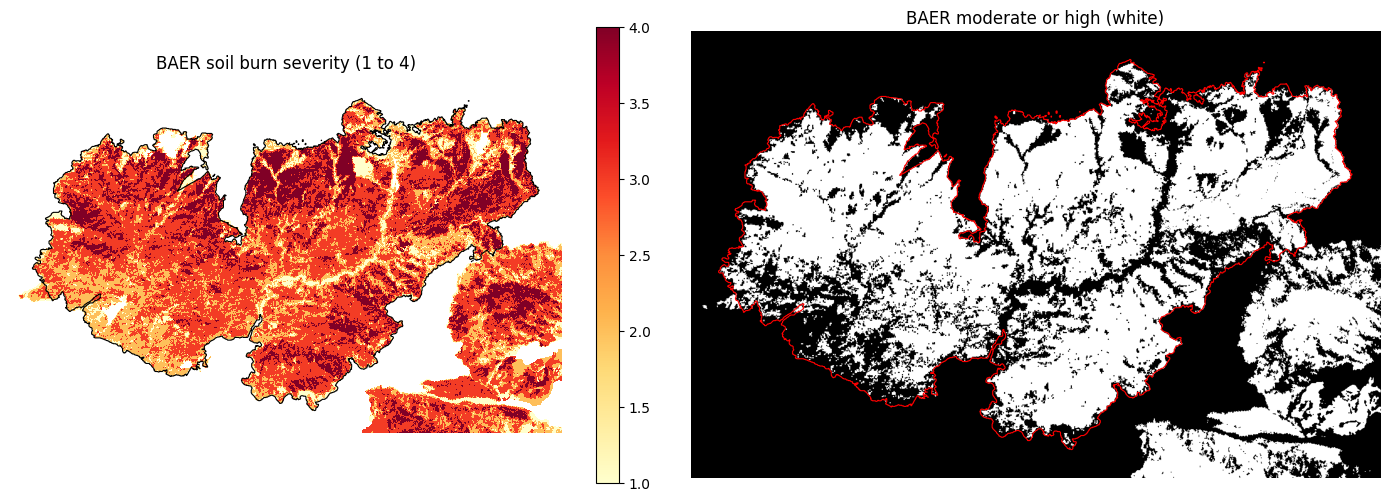

In [17]:
# Cell 17 --- fetch the BAER soil burn severity raster

import numpy as np
import requests
import rasterio
from rasterio.io import MemoryFile
from rasterio import features

SBS_DIR = FIRE_DIR / 'baer'
SBS_PATH = SBS_DIR / f"{CONFIG['fire_id']}_sbs.tif"

ENDPOINTS = [
    ('geoplatform imagery',
     'https://imagery.geoplatform.gov/iipp/rest/services/Fire_Aviation/'
     'USFS_EDW_BAER_SoilBurnSeverityClassification/ImageServer'),
    ('USFS EDW fsgisx03',
     'https://apps.fs.usda.gov/fsgisx03/rest/services/wo_nfs_gtac/'
     'EDW_BAERSoilBurnSeverityClassification_01/ImageServer'),
    ('USFS EDW fsgisx01',
     'https://apps.fs.usda.gov/fsgisx01/rest/services/wo_nfs_gtac/'
     'EDW_BAERSoilBurnSeverityClassification_01/ImageServer'),
]

# Export extent in the working UTM CRS, perimeter plus 1 km
pb = perim_utm.total_bounds
margin = 1000
export_bbox = (pb[0] - margin, pb[1] - margin, pb[2] + margin, pb[3] + margin)
width = int((export_bbox[2] - export_bbox[0]) / 20)
height = int((export_bbox[3] - export_bbox[1]) / 20)
target_epsg = int(TARGET_CRS.split(':')[1])
print(f'Export request: {width} x {height} px at 20 m, {TARGET_CRS}')

sbs, sbs_transform, SBS_SOURCE = None, None, None
for ep_label, base in ENDPOINTS:
    try:
        info = requests.get(base, params={'f': 'json'}, timeout=60).json()
        if 'error' in info:
            print(f'[skip] {ep_label}: {info["error"].get("message")}')
            continue
        print(f'[ok  ] {ep_label}: "{info.get("name")}", pixel type {info.get("pixelType")}')
    except Exception as e:
        print(f'[skip] {ep_label}: {type(e).__name__}')
        continue
    try:
        resp = requests.get(f'{base}/exportImage', params={
            'bbox': ','.join(str(v) for v in export_bbox),
            'bboxSR': target_epsg, 'imageSR': target_epsg,
            'size': f'{width},{height}',
            'format': 'tiff', 'pixelType': 'U8',
            'noData': 0, 'interpolation': 'RSP_NearestNeighbor',
            'f': 'image',
        }, timeout=300)
        resp.raise_for_status()
        if resp.headers.get('content-type', '').startswith('application/json'):
            print(f'[fail] {ep_label}: {resp.text[:200]}')
            continue
        with MemoryFile(resp.content) as mem, mem.open() as src:
            sbs = src.read(1)
            sbs_transform = src.transform
        SBS_SOURCE = ep_label
        print(f'[got ] {ep_label}: {sbs.shape}, {len(resp.content) / 1e6:.2f} MB')
        break
    except Exception as e:
        print(f'[fail] {ep_label}: {type(e).__name__}: {e}')

if sbs is None:
    raise RuntimeError('No BAER SBS raster returned. The service URLs may have moved.')

CLASS_NAMES = {0: 'nodata / outside', 1: 'unburned to very low', 2: 'low', 3: 'moderate', 4: 'high'}
vals, counts = np.unique(sbs, return_counts=True)
print('\n--- Class histogram over the export window ---')
for v, c in zip(vals, counts):
    print(f'  {v:>3} {CLASS_NAMES.get(int(v), "?"):22s} {c:>10,} px ({c / sbs.size:6.1%})')

# --- Inside the perimeter only ------------------------------------------------
burn_sbs = features.rasterize([(perim_geom, 1)], out_shape=sbs.shape,
                              transform=sbs_transform, fill=0, dtype='uint8').astype(bool)
sbs_inside = sbs[burn_sbs]
sbs_classified = sbs_inside[sbs_inside > 0]
baer_coverage = sbs_classified.size / max(int(burn_sbs.sum()), 1)
HAS_BAER = baer_coverage >= 0.90

print('\n--- Inside the fire perimeter ---')
print(f'pixels in perimeter : {burn_sbs.sum():,}')
print(f'with an SBS class   : {sbs_classified.size:,} ({baer_coverage:.1%} coverage)')
if sbs_classified.size:
    for v in (1, 2, 3, 4):
        n = int((sbs_classified == v).sum())
        print(f'  {CLASS_NAMES[v]:22s} {n:>10,} px ({n / sbs_classified.size:6.1%})')
    baer_mh_frac = np.isin(sbs_classified, [3, 4]).mean()
    print(f'\nmoderate or high    : {baer_mh_frac:.1%} (BAER)')
    print(f'this project, dNBR  : {mh10[burn_dem].mean():.1%} (Cell 13)')
print(f'\nHAS_BAER = {HAS_BAER}' + ('' if HAS_BAER else '  <-- anchor runs will be skipped'))

prof = {'driver': 'GTiff', 'height': sbs.shape[0], 'width': sbs.shape[1],
        'count': 1, 'dtype': 'uint8', 'nodata': 0, 'crs': TARGET_CRS,
        'transform': sbs_transform, 'compress': 'deflate', 'tiled': True}
with rasterio.open(SBS_PATH, 'w', **prof) as dst:
    dst.write(sbs.astype('uint8'), 1)
    dst.set_band_description(1, 'BAER_soil_burn_severity_1to4')
    dst.update_tags(source=SBS_SOURCE, fire=f"{CONFIG['display_name']} {CONFIG['target_year']}",
                    classes='1 unburned-verylow, 2 low, 3 moderate, 4 high')
print(f'Saved -> {SBS_PATH}')

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
im = ax[0].imshow(np.where(sbs > 0, sbs, np.nan), cmap='YlOrRd', vmin=1, vmax=4, interpolation='nearest')
ax[0].contour(burn_sbs.astype(float), levels=[0.5], colors='black', linewidths=0.8)
ax[0].set_title('BAER soil burn severity (1 to 4)'); ax[0].axis('off')
plt.colorbar(im, ax=ax[0], shrink=0.8)
ax[1].imshow(np.isin(sbs, [3, 4]), cmap='gray')
ax[1].contour(burn_sbs.astype(float), levels=[0.5], colors='red', linewidths=0.8)
ax[1].set_title('BAER moderate or high (white)'); ax[1].axis('off')
plt.tight_layout(); plt.show()

## Cell 18: Sensitivity setup

Sets up the parameter sweep:
* **Envelope runs (6):** dNBR threshold 200 / 270 / 350, times soil rule drop / zero.
* **Anchor runs (2):** BAER field severity in place of dNBR, times both soil rules.

Re-reads the saved basin label raster and basins so the sensitivity analysis works from exactly what was written to Drive, the same way notebook 04 did.

**What to check:** every file reads OK, and the label grid matches the DEM grid.

In [18]:
# Cell 18 --- sensitivity setup, paths, and constants

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from debrisflow import terrain, severity, soils, m1, sensitivity
for mod in (terrain, severity, soils, m1, sensitivity):
    importlib.reload(mod)

if not HAS_BAER:
    raise RuntimeError('No usable BAER raster for this fire (Cell 17). The anchor runs need it. '
                       'Running without anchors is not built yet.')

print(f'sensitivity requires: {sensitivity.REQUIRED_COLUMNS}')
print(f'High cutoff         : p >= {sensitivity.HIGH_P}')

OUT_DIR = FIRE_DIR / 'sensitivity'
FID = CONFIG['fire_id']
PATHS = {
    'dem':      FIRE_DIR / 'terrain' / f'{FID}_dem_10m.tif',
    'labels':   FIRE_DIR / 'terrain' / f'{FID}_basin_labels_10m.tif',
    'basins':   FIRE_DIR / 'terrain' / f'{FID}_basins.geojson',
    'dnbr':     FIRE_DIR / 'severity' / f'{FID}_dnbr_20m.tif',
    'baer':     FIRE_DIR / 'baer' / f'{FID}_sbs.tif',
    'soils':    FIRE_DIR / 'soils' / 'statsgo_mapunits.geojson',
    'baseline': FIRE_DIR / 'model' / f'{FID}_basins_scored.geojson',
}
print('\nChecking required files:')
for k, p in PATHS.items():
    print(f'{k:9s} {"OK " if p.exists() else "MISSING"} {p.stat().st_size / 1e6 if p.exists() else 0:7.2f} MB')

CELL = 10
SLOPE_THRESHOLD = 23.0
DNBR_LEVELS = {'t200': 200.0, 't270': 270.0, 't350': 350.0}
SOIL_RULES = {'drop': 'dropped and renormalised', 'zero': 'nulls zeroed'}
ENVELOPE_RUNS = [f'{t}_{s}' for s in SOIL_RULES for t in DNBR_LEVELS]
ANCHOR_RUNS = [f'baer_{s}' for s in SOIL_RULES]
print(f'\nenvelope: {ENVELOPE_RUNS}')
print(f'anchors : {ANCHOR_RUNS}')

# Separate name from Cell 12's `labels`: this is the saved raster, burned basins only.
with rasterio.open(PATHS['labels']) as src:
    sens_labels = src.read(1)
    grid_transform = src.transform
    grid_crs = src.crs
grid_shape = sens_labels.shape
assert grid_shape == dem.shape, 'label raster and DEM differ in shape'
assert np.allclose([grid_transform.c, grid_transform.f], [dem_transform.c, dem_transform.f]), \
    'label raster and DEM have different origins'
print(f'\ngrid   : {grid_shape[1]} x {grid_shape[0]} at {abs(grid_transform.a):.0f} m, {grid_crs}')

basins_gdf = gpd.read_file(PATHS['basins']).to_crs(TARGET_CRS)
BASIN_IDS = sorted(int(i) for i in basins_gdf['id'].unique())
print(f'basins : {len(BASIN_IDS)}  ids {min(BASIN_IDS)} to {max(BASIN_IDS)}')

sensitivity requires: ('basin_id', 'run_id', 'T', 'F', 'S', 'threshold_mm_hr', 'p_24')
High cutoff         : p >= 0.6

Checking required files:
dem       OK    36.91 MB
labels    OK     0.15 MB
basins    OK     1.80 MB
dnbr      OK     6.12 MB
baer      OK     0.08 MB
soils     OK     3.53 MB
baseline  OK     1.88 MB

envelope: ['t200_drop', 't270_drop', 't350_drop', 't200_zero', 't270_zero', 't350_zero']
anchors : ['baer_drop', 'baer_zero']

grid   : 3864 x 2996 at 10 m, EPSG:32611
basins : 171  ids 1 to 297


## Cell 19: Parameter sweep, score all 8 combinations

Computes T under four severity masks (three dNBR thresholds and BAER), F once, and S under both soil rules, then scores all 8 runs for every basin.

**Fence rule:** BAER severity is clipped to the fire perimeter. The BAER mosaic shows every assessed fire in the region, and basins reach outside the perimeter, so without the clip a basin can pick up severity from a neighbouring, older fire. On Line this created 4 false "under-warning" basins. dNBR is not clipped: it measures change between the two scene dates, so an old neighbouring scar shows up as roughly zero change anyway.

Ends with the **baseline reproduction check**: the `t270_drop` run must reproduce the Cell 15 scores to 1e-6. The fence rule does not touch that run.

**What to check:** `Reproduces the Cell 15 baseline`, and no implausible-median warning.

In [19]:
# Cell 19 --- parameter sweep: T, F, S under each setting, then score 8 runs

from rasterio.warp import reproject
from rasterio.enums import Resampling
from scipy import ndimage

# --- 1. BAER onto the 10 m grid, nearest neighbour ----------------------------
sbs10 = np.zeros(grid_shape, dtype='uint8')
reproject(source=sbs, destination=sbs10,
          src_transform=sbs_transform, src_crs=TARGET_CRS,
          dst_transform=grid_transform, dst_crs=grid_crs,
          resampling=Resampling.nearest, src_nodata=0, dst_nodata=0)
sens_in_basin = sens_labels > 0
print(f'BAER coverage of basin area (before fence): {(sbs10 > 0)[sens_in_basin].mean():.1%}')

# --- 2. Severity masks --------------------------------------------------------
# t270 goes through the tested function, as in notebook 04.
MASKS = {t: severity.moderate_high_mask(dnbr10) if lvl == 270.0
            else (dnbr10 >= lvl) & np.isfinite(dnbr10)
         for t, lvl in DNBR_LEVELS.items()}

# Fence rule: only BAER severity inside this fire's perimeter counts.
# burn_dem is the perimeter rasterised onto this same 10 m grid (Cell 10).
baer_unfenced = np.isin(sbs10, [3, 4])
MASKS['baer'] = baer_unfenced & burn_dem
n_fenced_out = int((baer_unfenced & ~burn_dem & sens_in_basin).sum())
print(f'BAER moderate/high cells removed by the fence (inside basins): {n_fenced_out:,} '
      f'({n_fenced_out * 100 / 1e6:.2f} km2)')

print('\nmask   mod-or-high %   steep AND burned %')
for name, mask in MASKS.items():
    print(f'{name:6s} {mask[sens_in_basin].mean():13.1%} {(mask & steep)[sens_in_basin].mean():19.1%}')

# --- 3. T per mask, F once ----------------------------------------------------
sens_slices = ndimage.find_objects(sens_labels)
T_by_mask = {name: {} for name in MASKS}
F_by_basin = {}
for bid in BASIN_IDS:
    sl = sens_slices[bid - 1]
    bmask = sens_labels[sl] == bid
    for name, mask in MASKS.items():
        T_by_mask[name][bid] = float(terrain.basin_T(steep[sl], mask[sl], bmask))
    F_by_basin[bid] = max(float(severity.basin_F(dnbr10[sl], bmask)), 0.0)

# --- 4. S under both soil rules -----------------------------------------------
kf_dropped = {k: v[0] for k, v in kf_lookup.items()}     # nulls dropped, renormalised

grouped = soils.group_rows_by_component(kf_rows)
by_mu = {}
for cokey, comp in grouped.items():
    by_mu.setdefault(str(comp['mukey']), []).append((comp['comppct'], comp['horizons']))


def surface_kf(horizons):
    return horizons[0][1] if horizons else np.nan


kf_zeroed = {}                                           # nulls counted as zero
for mukey, comps in by_mu.items():
    pcts = [c[0] for c in comps]
    surf = [surface_kf(c[1]) for c in comps]
    kf_zeroed[mukey], _ = soils.weighted_mean([0.0 if (v != v) else v for v in surf], pcts)

S_by_rule = {'drop': {}, 'zero': {}}
for bid, grp in inter.groupby('id'):
    for rule, lookup in (('drop', kf_dropped), ('zero', kf_zeroed)):
        kfs = [lookup.get(str(k), np.nan) for k in grp.mukey]
        val, _ = soils.weighted_mean(kfs, grp.area_m2.tolist())
        S_by_rule[rule][int(bid)] = float(val)

missing_s = [b for b in BASIN_IDS if S_by_rule['drop'].get(b, np.nan) != S_by_rule['drop'].get(b, np.nan)]
if missing_s:
    raise RuntimeError(f'{len(missing_s)} basins have no usable S: {missing_s[:10]}')

# --- 5. Score all runs --------------------------------------------------------
RUN_SPEC = {}
for rule in SOIL_RULES:
    for tname in DNBR_LEVELS:
        RUN_SPEC[f'{tname}_{rule}'] = (tname, rule, 'envelope')
    RUN_SPEC[f'baer_{rule}'] = ('baer', rule, 'anchor')

records = []
for run_id, (mask_name, rule, kind) in RUN_SPEC.items():
    for bid in BASIN_IDS:
        T_val, F_val, S_val = T_by_mask[mask_name][bid], F_by_basin[bid], S_by_rule[rule][bid]
        bv = m1.BasinVariables(T=T_val, F=F_val, S=S_val)
        p24 = float(m1.likelihood(bv, REFERENCE_STORM, convention=INTENSITY, duration_min=15))
        try:
            thr = float(m1.accumulation(bv, target_p=0.5, duration_min=15, out_convention=INTENSITY))
        except Exception:
            thr = np.inf
        records.append({'basin_id': int(bid), 'run_id': run_id, 'T': T_val, 'F': F_val, 'S': S_val,
                        'threshold_mm_hr': thr, 'p_24': p24, 'severity_source': mask_name,
                        'soil_rule': rule, 'kind': kind})

runs_df = pd.DataFrame(records)
print(f'\nrows: {len(runs_df):,}  (expected {len(RUN_SPEC) * len(BASIN_IDS):,})')
print('\nmedian threshold by run (mm/hr):')
print(runs_df.groupby('run_id').threshold_mm_hr.median().round(2).to_string())

med_all = runs_df.threshold_mm_hr.replace([np.inf, -np.inf], np.nan).median()
if not (2 < med_all < 200):
    print(f'\nWARNING: median threshold {med_all:.1f} mm/hr is implausible. Check the rainfall convention.')

# --- 6. Baseline reproduction check -------------------------------------------
sweep_base = runs_df[runs_df.run_id == 't270_drop'].set_index('basin_id').sort_index()
main_base = gdf_m.assign(id=gdf_m['id'].astype(int)).set_index('id').sort_index()
common_ids = sweep_base.index.intersection(main_base.index)
print(f'\n--- Sweep t270_drop vs Cell 15, {len(common_ids)} basins ---')
worst_base = 0.0
for sweep_col, main_col in (('T', 'T'), ('F', 'F_used'), ('S', 'S'),
                            ('threshold_mm_hr', 'threshold_mm_hr'), ('p_24', 'p_24')):
    a = pd.to_numeric(sweep_base.loc[common_ids, sweep_col], errors='coerce').replace([np.inf, -np.inf], np.nan)
    b = pd.to_numeric(main_base.loc[common_ids, main_col], errors='coerce').replace([np.inf, -np.inf], np.nan)
    both = a.notna() & b.notna()
    d = (a[both] - b[both]).abs()
    worst_base = max(worst_base, float(d.max()))
    print(f'{sweep_col:16s} max abs diff {d.max():.3e}')
print('\n>>> Reproduces the Cell 15 baseline.' if worst_base < 1e-6
      else '\n>>> DISAGREES with Cell 15. Do not trust anything below this cell.')

BAER coverage of basin area (before fence): 68.2%
BAER moderate/high cells removed by the fence (inside basins): 41,458 (4.15 km2)

mask   mod-or-high %   steep AND burned %
t200           60.5%               42.4%
t270           57.3%               40.1%
t350           53.1%               37.0%
baer           47.4%               33.0%

rows: 1,368  (expected 1,368)

median threshold by run (mm/hr):
run_id
baer_drop    20.36
baer_zero    21.69
t200_drop    18.69
t200_zero    19.70
t270_drop    19.02
t270_zero    20.15
t350_drop    19.52
t350_zero    20.44

--- Sweep t270_drop vs Cell 15, 171 basins ---
T                max abs diff 0.000e+00
F                max abs diff 0.000e+00
S                max abs diff 0.000e+00
threshold_mm_hr  max abs diff 0.000e+00
p_24             max abs diff 0.000e+00

>>> Reproduces the Cell 15 baseline.


## Cell 20: Envelope, stability classes, and the BAER anchor

Collapses the 6 envelope runs into a range per basin, which shows how far the threshold moves under defensible parameter choices.

**Stability class** at 24 mm/hr:
* `always`: High in all 6 runs.
* `sometimes`: flips depending on the parameter choice.
* `never`: never High.

Then checks where the BAER-based threshold sits relative to each basin's range. **Above** the range means the field severity says less hazardous than every parameter choice here, which is what "over-warns" means.

Saves the CSVs and `sensitivity_findings.json`.

**What to check.** Bridge reference: median spread 1.70 mm/hr; 140 always, 17 sometimes, 80 never; BAER above the range in 87 of 237, below in 0.

validate_runs passed.

--- Threshold envelope across the 6 parameter runs ---
       threshold_min  threshold_median  threshold_max  threshold_spread
count         171.00            171.00         171.00            171.00
mean           27.21             29.79          32.87              5.66
std            19.11             22.09          25.60              7.34
min            12.09             12.24          12.39              0.19
25%            16.08             16.57          17.17              0.93
50%            18.69             19.64          20.44              2.23
75%            27.50             31.87          35.83              7.47
max            86.04             95.88         106.62             35.41

median basin: 19.6 mm/hr, ranging 18.7 to 20.4
median spread across parameter choices: 2.23 mm/hr

--- Stability classes at 24 mm/hr ---
stability
always       92
never        59
sometimes    20

--- BAER anchor agreement (dropped soil rule) ---
stability  agreement       

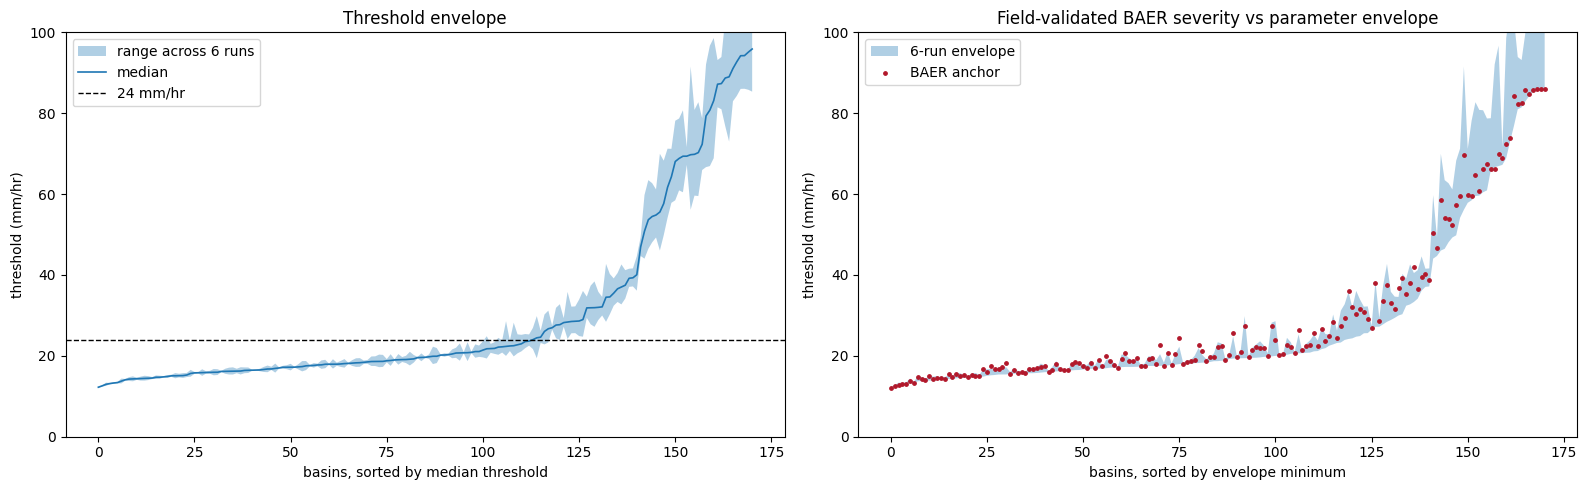

In [20]:
# Cell 20 --- validate, aggregate, compare anchors, save findings

sensitivity.validate_runs(runs_df, runs=ENVELOPE_RUNS + ANCHOR_RUNS)
print('validate_runs passed.')

env = sensitivity.threshold_envelope(runs_df, ENVELOPE_RUNS)
stab = sensitivity.stability_class(runs_df, ENVELOPE_RUNS)
anch = sensitivity.anchor_agreement(runs_df, ENVELOPE_RUNS, ANCHOR_RUNS)

MIN_C, MED_C, MAX_C, SPREAD_C = 'threshold_min', 'threshold_median', 'threshold_max', 'threshold_spread'
env_num = env.copy()
for c in (MIN_C, MED_C, MAX_C, SPREAD_C):
    env_num[c] = pd.to_numeric(env_num[c], errors='coerce').replace([np.inf, -np.inf], np.nan)
env_finite = env_num[env_num[SPREAD_C].notna()]

print('\n--- Threshold envelope across the 6 parameter runs ---')
print(env_finite[[MIN_C, MED_C, MAX_C, SPREAD_C]].describe().round(2).to_string())
median_spread = float(env_finite[SPREAD_C].median())
print(f'\nmedian basin: {env_finite[MED_C].median():.1f} mm/hr, ranging '
      f'{env_finite[MIN_C].median():.1f} to {env_finite[MAX_C].median():.1f}')
print(f'median spread across parameter choices: {median_spread:.2f} mm/hr')

STAB_COL = [c for c in stab.columns if stab[c].dtype == object and c != 'basin_id'][0]
stability_counts = stab[STAB_COL].value_counts().to_dict()
print(f'\n--- Stability classes at {REFERENCE_STORM} mm/hr ---')
print(stab[STAB_COL].value_counts().to_string())

print('\n--- BAER anchor agreement (dropped soil rule) ---')
print(anch[anch.run_id == 'baer_drop'].groupby(['stability', 'agreement']).size().to_string())

baer_thr = runs_df[runs_df.run_id == 'baer_drop'].set_index('basin_id')['threshold_mm_hr']
cmp_df = env_num.set_index('basin_id').join(baer_thr.rename('baer_threshold'))
cmp_ok = cmp_df[[MIN_C, MAX_C, 'baer_threshold']].replace([np.inf, -np.inf], np.nan).dropna()
baer_inside = (cmp_ok.baer_threshold >= cmp_ok[MIN_C]) & (cmp_ok.baer_threshold <= cmp_ok[MAX_C])
n_baer_above = int((cmp_ok.baer_threshold > cmp_ok[MAX_C]).sum())
n_baer_below = int((cmp_ok.baer_threshold < cmp_ok[MIN_C]).sum())
print(f'\nBAER threshold inside the 6-run envelope : {baer_inside.sum()} of {len(cmp_ok)} ({baer_inside.mean():.1%})')
print(f'above the envelope max (less hazardous)  : {n_baer_above}')
print(f'below the envelope min (more hazardous)  : {n_baer_below}')

# --- Save tables and findings -------------------------------------------------
runs_df.to_csv(OUT_DIR / 'sensitivity_runs_long.csv', index=False)
env.to_csv(OUT_DIR / 'sensitivity_envelope.csv', index=False)
stab.to_csv(OUT_DIR / 'sensitivity_stability.csv', index=False)
anch.to_csv(OUT_DIR / 'sensitivity_anchors.csv', index=False)

findings = {
    'fire_id': CONFIG['fire_id'],
    'design': {'envelope_runs': ENVELOPE_RUNS, 'anchor_runs': ANCHOR_RUNS,
               'dnbr_levels': DNBR_LEVELS, 'soil_rules': list(SOIL_RULES),
               'basins': len(BASIN_IDS), 'rows': int(len(runs_df)),
               'reference_storm_mm_hr': REFERENCE_STORM,
               'high_cutoff_p': float(sensitivity.HIGH_P)},
    'envelope': {'median_of_medians': float(env_finite[MED_C].median()),
                 'median_of_minima': float(env_finite[MIN_C].median()),
                 'median_of_maxima': float(env_finite[MAX_C].median()),
                 'median_spread': median_spread,
                 'basins_spread_over_5': int((env_finite[SPREAD_C] > 5).sum())},
    'stability': stability_counts,
    'anchors': {'baer_inside_envelope': int(baer_inside.sum()),
                'baer_above_max': n_baer_above, 'baer_below_min': n_baer_below,
                'n_compared': int(len(cmp_ok))},
}
with open(OUT_DIR / 'sensitivity_findings.json', 'w') as f:
    json.dump(findings, f, indent=2, default=str)
print(f'\nSaved CSVs and sensitivity_findings.json -> {OUT_DIR}')

# --- Plots --------------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
order = env_finite.sort_values(MED_C)
x = np.arange(len(order))
ax[0].fill_between(x, order[MIN_C], order[MAX_C], alpha=0.35, label='range across 6 runs')
ax[0].plot(x, order[MED_C], lw=1.2, label='median')
ax[0].axhline(REFERENCE_STORM, color='k', ls='--', lw=1, label=f'{REFERENCE_STORM} mm/hr')
ax[0].set_xlabel('basins, sorted by median threshold'); ax[0].set_ylabel('threshold (mm/hr)')
ax[0].set_ylim(0, 100); ax[0].legend(); ax[0].set_title('Threshold envelope')

o = cmp_ok.sort_values(MIN_C)
xx = np.arange(len(o))
ax[1].fill_between(xx, o[MIN_C], o[MAX_C], alpha=0.35, label='6-run envelope')
ax[1].scatter(xx, o.baer_threshold, s=6, color='#b2182b', label='BAER anchor')
ax[1].set_ylim(0, 100); ax[1].set_xlabel('basins, sorted by envelope minimum')
ax[1].set_ylabel('threshold (mm/hr)'); ax[1].legend()
ax[1].set_title('Field-validated BAER severity vs parameter envelope')
plt.tight_layout(); plt.show()

## Cell 20b: Inspect any basin where BAER says "more dangerous"

Lists every basin whose BAER threshold is **below** the whole parameter envelope, meaning field severity says it floods at less rain than any of our parameter choices predict. These are the only possible under-warnings, so each one gets looked at individually.

**How to read it**
* `gap_mm_hr`: how much lower BAER's threshold is than our lowest run. Compare it to the median spread from Cell 20. A gap smaller than that is within the noise of our own parameter choices.
* `stability`: if the basin is already `always` or `sometimes` High, the pipeline was already warning about it at 24 mm/hr. That is a threshold disagreement, not a missed warning.
* The map shows where it sits. Edge basins that barely touch the fire are the usual suspects.

Basins where BAER threshold is below the whole envelope: 1 of 171
(median envelope spread for comparison: 2.23 mm/hr)

          threshold_min  threshold_max  baer_threshold  gap_mm_hr  T_baer_drop  T_t200_drop  T_t270_drop  T_t350_drop stability  area_km2  overlap_fraction
basin_id                                                                                                                                                   
183              66.671         92.067          66.226      0.445         0.02        0.016        0.016        0.016     never      0.28             0.182

In plain terms:
  basin 183: BAER says 66.2 mm/hr, our lowest run says 66.7, so BAER is 0.4 mm/hr more cautious. At 24 mm/hr the pipeline already calls it "never" High.


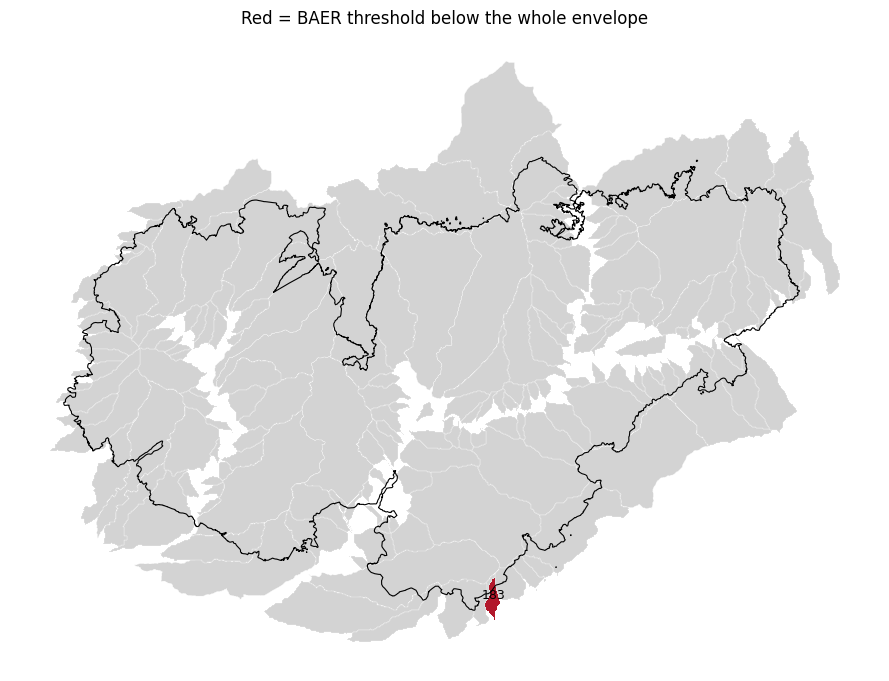

In [21]:
# Cell 20b --- inspect basins where BAER gives a LOWER threshold than every parameter run

below_ids = cmp_ok.index[cmp_ok.baer_threshold < cmp_ok[MIN_C]].tolist()
print(f'Basins where BAER threshold is below the whole envelope: {len(below_ids)} of {len(cmp_ok)}')
print(f'(median envelope spread for comparison: {median_spread:.2f} mm/hr)\n')

if below_ids:
    # T under each severity source, dropped-soil rule
    T_wide = (runs_df[runs_df.run_id.isin(['t200_drop', 't270_drop', 't350_drop', 'baer_drop'])]
              .pivot(index='basin_id', columns='run_id', values='T'))

    below_info = cmp_ok.loc[below_ids, [MIN_C, MAX_C, 'baer_threshold']].copy()
    below_info['gap_mm_hr'] = below_info[MIN_C] - below_info['baer_threshold']
    below_info = below_info.join(T_wide.loc[below_ids].add_prefix('T_'))
    below_info = below_info.join(stab.set_index('basin_id')['stability'])
    basin_cols = [c for c in ('area_km2', 'overlap_fraction') if c in basins_gdf.columns]
    below_info = below_info.join(basins_gdf.set_index('id')[basin_cols])
    print(below_info.round(3).to_string())

    print('\nIn plain terms:')
    for bid, r in below_info.iterrows():
        print(f'  basin {bid}: BAER says {r.baer_threshold:.1f} mm/hr, our lowest run says '
              f'{r[MIN_C]:.1f}, so BAER is {r.gap_mm_hr:.1f} mm/hr more cautious. '
              f'At 24 mm/hr the pipeline already calls it "{r.stability}" High.')

    # --- Where is it? ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(9, 8))
    basins_gdf.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.2)
    basins_gdf[basins_gdf['id'].isin(below_ids)].plot(ax=ax, color='#b2182b')
    perim_utm.boundary.plot(ax=ax, color='black', linewidth=0.8)
    for bid in below_ids:
        pt = basins_gdf.loc[basins_gdf['id'] == bid, 'geometry'].iloc[0].representative_point()
        ax.annotate(str(bid), (pt.x, pt.y), fontsize=9, ha='center')
    ax.set_title('Red = BAER threshold below the whole envelope')
    ax.axis('off')
    plt.tight_layout(); plt.show()
else:
    print('None. BAER never says a basin is more dangerous than every parameter run.')

## Cell 21: Export the web map data

1. **GeoJSON:** baseline values, envelope, stability and BAER comparison per basin. Disconnected fragments under 1000 m² are dropped (display only). Coordinates are rounded to 6 decimals, **never simplified**, because simplifying each polygon separately opens slivers along shared boundaries.
2. **Manifest:** reads the current `web/data/fires.json` from the repo, replaces or adds this fire's entry, and writes the merged result. Other fires are kept.

Download both files from `web_export/` and put them in the repo's `web/data/`. Remember to bump `?v=N` in `index.html` only if you also edited the CSS or JS.

In [22]:
# Cell 21 --- export the web map data and merge the manifest

from shapely.geometry import MultiPolygon

WEB_DIR = FIRE_DIR / 'web_export'
MIN_PART_M2 = 1000.0              # ten 10 m cells

# --- Per-basin table ------------------------------------------------------------
baseline_run = runs_df[runs_df.run_id == 't270_drop'].set_index('basin_id')
baer_run = runs_df[runs_df.run_id == 'baer_drop'].set_index('basin_id')
env_i = env.set_index('basin_id')
stab_i = stab.set_index('basin_id')
anch_i = anch[anch.run_id == 'baer_drop'].set_index('basin_id')

tbl = pd.DataFrame(index=sorted(baseline_run.index))
tbl['T'] = baseline_run['T']
tbl['F'] = baseline_run['F']
tbl['S'] = baseline_run['S']
tbl['p_24'] = baseline_run['p_24']
tbl['threshold_mm_hr'] = baseline_run['threshold_mm_hr']
tbl['thr_min'] = env_i['threshold_min']
tbl['thr_max'] = env_i['threshold_max']
tbl['thr_spread'] = env_i['threshold_spread']
tbl['stability'] = stab_i['stability']
tbl['frac_high'] = stab_i['frac_high']
tbl['baer_threshold'] = baer_run['threshold_mm_hr']
tbl['baer_agreement'] = anch_i['agreement']
tbl = tbl.replace([np.inf, -np.inf], np.nan)

geo = basins_gdf[['id', 'area_km2', 'geometry']].copy()
geo['id'] = geo['id'].astype(int)
web = geo.merge(tbl.reset_index().rename(columns={'index': 'id'}), on='id', how='left')

# --- Drop tiny disconnected parts (display only) ---------------------------------
def drop_small_parts(geom, min_area):
    """Keep polygon parts above min_area. Always keeps the largest part."""
    if geom is None or geom.is_empty:
        return geom
    parts = list(geom.geoms) if geom.geom_type == 'MultiPolygon' else [geom]
    if len(parts) == 1:
        return geom
    kept = [p for p in parts if p.area >= min_area] or [max(parts, key=lambda p: p.area)]
    return kept[0] if len(kept) == 1 else MultiPolygon(kept)


def count_parts(series):
    return sum(len(g.geoms) if g.geom_type == 'MultiPolygon' else 1 for g in series)


area_before, parts_before = web.geometry.area.sum(), count_parts(web.geometry)
web['geometry'] = web.geometry.apply(drop_small_parts, min_area=MIN_PART_M2)
area_after, parts_after = web.geometry.area.sum(), count_parts(web.geometry)
lost = area_before - area_after
print(f'polygon parts : {parts_before:,} -> {parts_after:,} ({parts_before - parts_after:,} dropped)')
print(f'area removed  : {lost:,.0f} m2 ({lost / area_before:.3%} of basin area)')
if lost / area_before > 0.005:
    print('WARNING: more than 0.5% of area removed. Lower MIN_PART_M2.')

# --- Reproject and round (NO simplify) -------------------------------------------
web = web.to_crs('EPSG:4326')


def round_coords(obj, nd=6):
    if isinstance(obj, (list, tuple)):
        return [round_coords(o, nd) for o in obj]
    if isinstance(obj, float):
        return round(obj, nd)
    return obj


web_gj = json.loads(web.to_json())
NUMERIC = ['area_km2', 'T', 'F', 'S', 'p_24', 'threshold_mm_hr',
           'thr_min', 'thr_max', 'thr_spread', 'frac_high', 'baer_threshold']
for feat in web_gj['features']:
    feat['geometry']['coordinates'] = round_coords(feat['geometry']['coordinates'])
    props = feat['properties']
    for k in NUMERIC:
        if k in props and props[k] is not None and props[k] == props[k]:
            props[k] = round(float(props[k]), 3)
        elif k in props:
            props[k] = None
    feat.pop('id', None)

geo_path = WEB_DIR / f"{CONFIG['fire_id']}.geojson"
with open(geo_path, 'w') as f:
    json.dump(web_gj, f, separators=(',', ':'))
print(f'\n{geo_path.name}: {len(web_gj["features"])} features, {geo_path.stat().st_size / 1e6:.2f} MB')

# --- Manifest entry for this fire --------------------------------------------------
web_bounds = web.total_bounds
med_thr = float(tbl.threshold_mm_hr.median())
web_centroid = web.geometry.union_all().centroid

fire_entry = {
    'id': CONFIG['fire_id'],
    'name': CONFIG['display_name'],
    'year': CONFIG['target_year'],
    'state': 'CA',
    'ignition': CONFIG['ignition_date'],
    'area_km2': round(area_km2, 1),
    'center': [round(float(web_centroid.x), 4), round(float(web_centroid.y), 4)],
    'bounds': [round(float(v), 4) for v in web_bounds],
    'basins': int(len(web)),
    'data': f"data/{CONFIG['fire_id']}.geojson",
    'severity_source': f"Sentinel-2 dNBR, {SCENES['pre']} to {SCENES['post']}",
    'has_baer_anchor': bool(HAS_BAER),
    'median_threshold_mm_hr': round(med_thr, 1),
    'envelope_spread_mm_hr': round(float(env_i.threshold_spread.median()), 2),
    'stability': stab['stability'].value_counts().to_dict(),
}

# --- Merge into the existing manifest so other fires are kept --------------------
repo_manifest = Path(REPO_DIR) / 'web' / 'data' / 'fires.json'
if repo_manifest.exists():
    with open(repo_manifest) as f:
        manifest = json.load(f)
    print(f'\nStarting from repo manifest: {[fe["id"] for fe in manifest.get("fires", [])]}')
else:
    manifest = {'fires': []}
    print('\nNo repo manifest found, starting a new one.')

fires = manifest.get('fires', [])
ids_now = [fe['id'] for fe in fires]
if CONFIG['fire_id'] in ids_now:
    fires[ids_now.index(CONFIG['fire_id'])] = fire_entry      # replace in place, keep order
    print(f"Replaced entry for {CONFIG['fire_id']}")
else:
    fires.append(fire_entry)
    print(f"Added entry for {CONFIG['fire_id']}")
manifest['fires'] = fires
manifest['generated'] = pd.Timestamp.now(tz='UTC').strftime('%Y-%m-%d')

man_path = WEB_DIR / 'fires.json'
with open(man_path, 'w') as f:
    json.dump(manifest, f, indent=2)
print(f'{man_path.name} written with {len(fires)} fire(s): {[fe["id"] for fe in fires]}')
print(json.dumps(fire_entry, indent=2))
print(f'\nDownload both from {WEB_DIR} and put them in web/data/.')

polygon parts : 280 -> 172 (108 dropped)
area removed  : 12,000 m2 (0.005% of basin area)

line_2024.geojson: 171 features, 1.70 MB

Starting from repo manifest: ['bridge_2024', 'line_2024']
Replaced entry for line_2024
fires.json written with 2 fire(s): ['bridge_2024', 'line_2024']
{
  "id": "line_2024",
  "name": "Line Fire",
  "year": 2024,
  "state": "CA",
  "ignition": "2024-09-05",
  "area_km2": 179.6,
  "center": [
    -117.0621,
    34.161
  ],
  "bounds": [
    -117.1898,
    34.0832,
    -116.9261,
    34.2443
  ],
  "basins": 171,
  "data": "data/line_2024.geojson",
  "severity_source": "Sentinel-2 dNBR, 2024-08-20 to 2024-10-19",
  "has_baer_anchor": true,
  "median_threshold_mm_hr": 19.0,
  "envelope_spread_mm_hr": 2.23,
  "stability": {
    "always": 92,
    "never": 59,
    "sometimes": 20
  }
}

Download both from /content/drive/MyDrive/postfire-debris-flow/line_2024/web_export and put them in web/data/.


## Cell 22: Regression check against a reference run

Only runs if `reference_dir` is set in `CONFIG`. Three comparisons, strongest last:

1. **Headline numbers** against the values recorded in the handoff (Bridge only).
2. **Every basin** against the repo's committed `web/data/<fire_id>.geojson`, rounded to 3 decimals.
3. **Every basin at full precision** against `<reference_dir>/model/<fire_id>_basins_scored.geojson`.

**Expected changes under the fence rule:** the reference runs used unfenced BAER, so `baer_threshold`, `baer_agreement` and the "BAER above envelope" count are *allowed* to differ. They are reported under "expected changes" and do not count toward the verdict. Everything else, including every dNBR-based number, must still match.

In [23]:
# Cell 22 --- regression check against a reference run

import numpy as np
import pandas as pd

# Columns the fence rule changes on purpose: reported, not counted as failures.
EXPECTED_TO_CHANGE = {'baer_threshold', 'baer_agreement'}

if REF_DIR is None:
    print('reference_dir is None. Nothing to compare. This is expected for a new fire.')
else:
    results = []           # (check, expected, got, passed, counts_toward_verdict)

    def record(check, expected, got, passed, counts=True):
        results.append((check, expected, got, bool(passed), counts))

    # --- 1. Headline numbers from the handoff -----------------------------------
    HEADLINE_EXPECTED = {
        'bridge_2024': {
            # check: (expected, got, tolerance). Handoff values are rounded, hence tolerances.
            'dNBR offset':                (-5.05, float(offset), 0.005),
            'unburned ring pixels':       (484963, int(unburned_mask.sum()), 0),
            'moderate-or-high (dNBR)':    (0.765, float(mh20[burn_mask].mean()), 0.0005),
            'basins':                     (237, len(BASIN_IDS), 0),
            'median threshold (mm/hr)':   (16.4, med_thr, 0.05),
            'median envelope spread':     (1.70, median_spread, 0.005),
            'always High':                (140, stability_counts.get('always', 0), 0),
            'sometimes High':             (17, stability_counts.get('sometimes', 0), 0),
            'never High':                 (80, stability_counts.get('never', 0), 0),
            # The fence can only remove basins from "below", so 0 must stay 0.
            'BAER below envelope':        (0, n_baer_below, 0),
        },
    }
    headline = HEADLINE_EXPECTED.get(CONFIG['fire_id'])
    print('--- 1. Headline numbers ---')
    if headline is None:
        print(f"No recorded headline numbers for {CONFIG['fire_id']}, skipped.")
    else:
        for check, (expected, got, tol) in headline.items():
            passed = abs(expected - got) <= tol
            got_txt = f'{got:.4f}' if isinstance(got, float) else str(got)
            record(check, expected, got_txt, passed)
            print(f'{"OK  " if passed else "DIFF"} {check:28s} expected {expected!s:>10}   got {got_txt:>10}')
        if CONFIG['fire_id'] == 'bridge_2024':
            print(f'INFO BAER above envelope        unfenced run: 87   fenced: {n_baer_above}   '
                  '(may only go up or stay the same)')

    # --- helper: compare two per-basin tables --------------------------------------
    def compare_basins(ours_df, ref_df, cols, tol, label):
        ours_i = ours_df.set_index('id')
        ref_i = ref_df.set_index('id')
        only_ours = sorted(set(ours_i.index) - set(ref_i.index))
        only_ref = sorted(set(ref_i.index) - set(ours_i.index))
        common = ours_i.index.intersection(ref_i.index)
        print(f'basins: {len(ours_i)} ours, {len(ref_i)} reference, {len(common)} in common')
        if only_ours or only_ref:
            print(f'  only in ours: {only_ours[:10]}   only in reference: {only_ref[:10]}')
        record(f'{label}: same basin ids', 0, len(only_ours) + len(only_ref),
               not only_ours and not only_ref)
        for col in cols:
            if col not in ours_i.columns or col not in ref_i.columns:
                print(f'  {col:16s} not present in both, skipped')
                continue
            counts = col not in EXPECTED_TO_CHANGE
            tag = '' if counts else '   (expected to change: fence rule)'
            a, b = ours_i.loc[common, col], ref_i.loc[common, col]
            if a.dtype == object or b.dtype == object:
                changed = a.astype(str) != b.astype(str)
                n_bad = int(changed.sum())
                print(f'  {col:16s} {"OK  " if n_bad == 0 else "DIFF"} {n_bad} basin(s) differ{tag}')
                if n_bad and not counts:
                    print(f'      basins: {sorted(changed[changed].index.tolist())[:15]}')
                record(f'{label}: {col}', 0, n_bad, n_bad == 0, counts)
                continue
            a = pd.to_numeric(a, errors='coerce').replace([np.inf, -np.inf], np.nan)
            b = pd.to_numeric(b, errors='coerce').replace([np.inf, -np.inf], np.nan)
            nan_mismatch = a.isna() != b.isna()
            both = a.notna() & b.notna()
            d = (a[both] - b[both]).abs()
            bad = (d > tol).reindex(a.index, fill_value=False) | nan_mismatch
            n_bad = int(bad.sum())
            worst = float(d.max()) if len(d) else 0.0
            print(f'  {col:16s} {"OK  " if n_bad == 0 else "DIFF"} {n_bad} basin(s) beyond {tol:g}, '
                  f'worst {worst:.3e}{tag}')
            if n_bad and not counts:
                print(f'      basins: {sorted(bad[bad].index.tolist())[:15]}')
            record(f'{label}: {col}', 0, n_bad, n_bad == 0, counts)

    # --- 2. Against the committed web GeoJSON (rounded to 3 decimals) ---------------
    print('\n--- 2. Every basin vs repo web/data GeoJSON (3 decimals) ---')
    ref_web_path = Path(REPO_DIR) / 'web' / 'data' / f"{CONFIG['fire_id']}.geojson"
    if ref_web_path.exists():
        with open(ref_web_path) as f:
            ref_web = pd.DataFrame([fe['properties'] for fe in json.load(f)['features']])
        ours_web = pd.DataFrame([fe['properties'] for fe in web_gj['features']])
        compare_basins(ours_web, ref_web,
                       ['area_km2', 'T', 'F', 'S', 'p_24', 'threshold_mm_hr', 'thr_min', 'thr_max',
                        'stability', 'baer_threshold', 'baer_agreement'],
                       tol=1.1e-3, label='web')
    else:
        print(f'{ref_web_path} not found, skipped.')

    # --- 3. Full precision against the reference scored GeoJSON -------------------
    print('\n--- 3. Every basin vs reference scored GeoJSON (full precision) ---')
    ref_scored_path = REF_DIR / 'model' / f"{CONFIG['fire_id']}_basins_scored.geojson"
    if ref_scored_path.exists():
        ref_scored = gpd.read_file(ref_scored_path).drop(columns='geometry')
        ours_scored = pd.DataFrame(gdf_m.drop(columns='geometry'))
        ref_scored['id'] = ref_scored['id'].astype(int)
        ours_scored['id'] = ours_scored['id'].astype(int)
        compare_basins(ours_scored, ref_scored,
                       ['area_km2', 'T', 'F_used', 'S', 'p_24', 'threshold_mm_hr'],
                       tol=1e-6, label='scored')
    else:
        print(f'{ref_scored_path} not found, skipped.')

    # --- Verdict --------------------------------------------------------------------
    counted = [r for r in results if r[4]]
    expected_changes = [r for r in results if not r[4] and not r[3]]
    n_fail = sum(1 for r in counted if not r[3])
    print('\n' + '=' * 72)
    if not counted:
        print('Nothing was compared.')
    elif n_fail == 0:
        print(f'REPRODUCES the reference run: all {len(counted)} counted checks passed.')
    else:
        print(f'{n_fail} of {len(counted)} counted checks differ:')
        for check, expected, got, passed, _ in counted:
            if not passed:
                print(f'  - {check}: expected {expected}, got {got}')
    if expected_changes:
        print('Expected changes from the fence rule (not failures):')
        for check, _, got, _, _ in expected_changes:
            print(f'  - {check}: {got} basin(s) changed')
    print('=' * 72)

--- 1. Headline numbers ---
No recorded headline numbers for line_2024, skipped.

--- 2. Every basin vs repo web/data GeoJSON (3 decimals) ---
basins: 171 ours, 171 reference, 171 in common
  area_km2         OK   0 basin(s) beyond 0.0011, worst 0.000e+00
  T                OK   0 basin(s) beyond 0.0011, worst 0.000e+00
  F                OK   0 basin(s) beyond 0.0011, worst 0.000e+00
  S                OK   0 basin(s) beyond 0.0011, worst 0.000e+00
  p_24             OK   0 basin(s) beyond 0.0011, worst 0.000e+00
  threshold_mm_hr  OK   0 basin(s) beyond 0.0011, worst 0.000e+00
  thr_min          OK   0 basin(s) beyond 0.0011, worst 0.000e+00
  thr_max          OK   0 basin(s) beyond 0.0011, worst 0.000e+00
  stability        OK   0 basin(s) differ
  baer_threshold   OK   0 basin(s) beyond 0.0011, worst 0.000e+00   (expected to change: fence rule)
  baer_agreement   OK   0 basin(s) differ   (expected to change: fence rule)

--- 3. Every basin vs reference scored GeoJSON (full precisio